In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 11)


In [4]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


In [5]:
display(user_df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,12500,12500,U0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,12500,146,2025-02-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_channel,12363,2,퍼포먼스광고,6852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,12379,2,iOS,7175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_agreed,12384,2,True,7984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_changed_date,1976,148,2025-05-29,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_day,12500,146,2025-02-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_month,12500,5,2025-02,4384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_weekday,12500,7,목,1828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_event_time,12453,12399,2025-01-05 08:56:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
display(event_df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,1757262,12453,U0006192,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_time,1757262,NaN,NaN,NaN,2025-04-03 07:09:49.614657,2025-01-01 07:00:07,2025-02-28 08:37:29.250000,2025-04-03 17:49:00,2025-05-05 09:58:57.750000,2025-06-30 22:59:51,NaN
event_type,1730806,10,앱실행,728657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,1515760,736281,e783135554,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_type,218882,3,리마인드,85830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_date,1757262,181,2025-02-28,16495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_month,1757262,6,2025-04,420330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_weekday,1757262,7,토,258973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_hour,1757262.0,NaN,NaN,NaN,14.444575,6.0,11.0,14.0,18.0,23.0,4.512299
is_log_issue_period,1757262,2,False,1736400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# 알림수신 - 오픈 패턴 분석
#### 알림은 실제 앱 재방문과 핵심 행동을 유도하고 있는가?

- 알림 오픈율 = 알림오픈 이벤트 수 / 알림수신 이벤트 수   
- 알림 반응 유저 비율 = 알림오픈 경험 유저 수 / 알림수신 경험 유저 수

In [7]:
# ============================================================
# 0. 알림 분석용 데이터 생성
# ============================================================

notification_events = ["알림수신", "알림오픈"]

# 알림 이벤트만 추출
alarm_log = event_df[event_df["event_type"].isin(notification_events)].copy()

# 이벤트 구분 플래그
alarm_log["is_alarm_receive"] = alarm_log["event_type"].eq("알림수신")
alarm_log["is_alarm_open"] = alarm_log["event_type"].eq("알림오픈")

# 유저 프로필 정보 붙이기
user_cols = [
    "user_id",
    "signup_date",
    "signup_month",
    "signup_weekday",
    "signup_channel",
    "is_notification_changed",
    "is_signup_log_issue_period",
    "is_no_event_user",
    "is_onboarding_completed"
]

alarm_log = alarm_log.merge(
    user_df[user_cols],
    on="user_id",
    how="left"
)

print("전체 알림 이벤트 수:", len(alarm_log))
print("알림수신 이벤트 수:", alarm_log["is_alarm_receive"].sum())
print("알림오픈 이벤트 수:", alarm_log["is_alarm_open"].sum())
print("알림 이벤트 발생 유저 수:", alarm_log["user_id"].nunique())

display(alarm_log.head())

전체 알림 이벤트 수: 215543
알림수신 이벤트 수: 194324
알림오픈 이벤트 수: 21219
알림 이벤트 발생 유저 수: 8139


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,is_alarm_receive,is_alarm_open,signup_date,signup_month,signup_weekday,signup_channel,is_notification_changed,is_signup_log_issue_period,is_no_event_user,is_onboarding_completed
0,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
1,U0000001,2025-01-26 15:18:00,알림수신,NaN,리마인드,2025-01-26,2025-01,일,15,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
2,U0000001,2025-01-27 11:42:00,알림수신,NaN,광고성,2025-01-27,2025-01,월,11,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
3,U0000001,2025-01-28 12:25:00,알림수신,NaN,리마인드,2025-01-28,2025-01,화,12,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
4,U0000001,2025-01-29 18:23:00,알림수신,NaN,리마인드,2025-01-29,2025-01,수,18,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True


In [8]:
# ============================================================
# 1. 전체 알림 오픈율
# ============================================================

receive_events = alarm_log["is_alarm_receive"].sum()
open_events = alarm_log["is_alarm_open"].sum()

receive_users = alarm_log.loc[alarm_log["is_alarm_receive"], "user_id"].nunique()
open_users = alarm_log.loc[alarm_log["is_alarm_open"], "user_id"].nunique()

overall_alarm_summary = pd.DataFrame({
    "알림수신_이벤트수": [receive_events],
    "알림오픈_이벤트수": [open_events],
    "이벤트기준_오픈율": [open_events / receive_events * 100 if receive_events > 0 else np.nan],
    "알림수신_유저수": [receive_users],
    "알림오픈_유저수": [open_users],
    "유저기준_오픈경험률": [open_users / receive_users * 100 if receive_users > 0 else np.nan]
})

display(overall_alarm_summary)

,알림수신_이벤트수,알림오픈_이벤트수,이벤트기준_오픈율,알림수신_유저수,알림오픈_유저수,유저기준_오픈경험률
0,194324,21219,10.919392,8139,5127,62.992997


In [9]:
# ============================================================
# 2. 알림 집계 함수
# ============================================================

def notification_summary(df, group_cols):
    """
    group_cols 기준으로
    알림수신 이벤트 수, 알림오픈 이벤트 수,
    알림수신 유저 수, 알림오픈 유저 수,
    이벤트 기준 오픈율, 유저 기준 오픈경험률을 계산하는 함수
    """

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    required_cols = set(group_cols + ["event_type", "user_id"])
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise KeyError(f"현재 데이터에 없는 컬럼입니다: {missing_cols}")

    # 이벤트 수 집계
    event_cnt = (
        df
        .groupby(group_cols + ["event_type"])
        .size()
        .unstack("event_type", fill_value=0)
    )

    # 필요한 이벤트 컬럼이 없을 경우 0으로 생성
    for col in ["알림수신", "알림오픈"]:
        if col not in event_cnt.columns:
            event_cnt[col] = 0

    event_cnt = event_cnt.rename(columns={
        "알림수신": "receive_events",
        "알림오픈": "open_events"
    })

    # 유저 수 집계
    user_cnt = (
        df
        .groupby(group_cols + ["event_type"])["user_id"]
        .nunique()
        .unstack("event_type", fill_value=0)
    )

    for col in ["알림수신", "알림오픈"]:
        if col not in user_cnt.columns:
            user_cnt[col] = 0

    user_cnt = user_cnt.rename(columns={
        "알림수신": "receive_users",
        "알림오픈": "open_users"
    })

    # 합치기
    result = event_cnt.join(user_cnt, how="outer").fillna(0).reset_index()

    # 오픈율 계산: 전체 요약 셀과 맞추기 위해 % 단위로 계산
    result["event_open_rate"] = np.where(
        result["receive_events"] > 0,
        result["open_events"] / result["receive_events"] * 100,
        np.nan
    )

    result["user_open_rate"] = np.where(
        result["receive_users"] > 0,
        result["open_users"] / result["receive_users"] * 100,
        np.nan
    )

    return result


In [10]:
# ============================================================
# 3. 월별 알림수신/오픈 패턴
# ============================================================

alarm_by_month = notification_summary(alarm_log, ["event_month"])

alarm_by_month = alarm_by_month.sort_values("event_month").reset_index(drop=True)

display(alarm_by_month)


event_type,event_month,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,10648,1665,1349,787,15.636739,58.339511
1,2025-02,32395,5067,3471,2236,15.641303,64.419476
2,2025-03,43163,4923,3201,2170,11.405602,67.791315
3,2025-04,49146,5399,3422,2345,10.985635,68.527177
4,2025-05,40457,2925,3226,1714,7.229898,53.130812
5,2025-06,18515,1240,1067,684,6.697272,64.104967


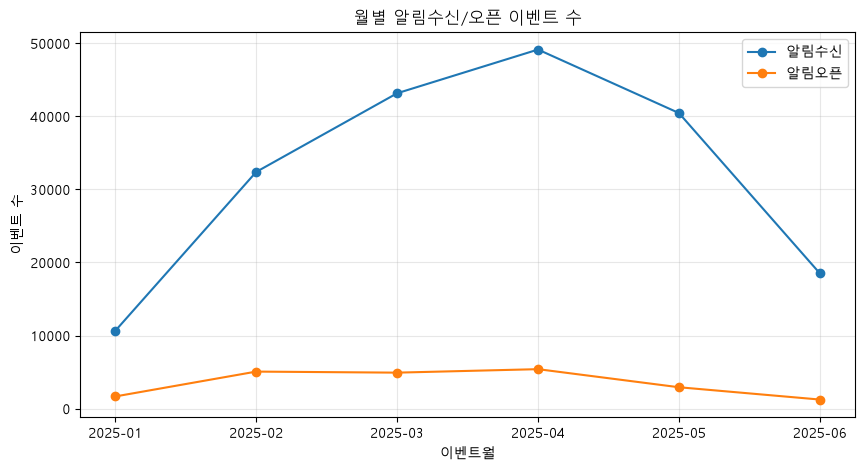

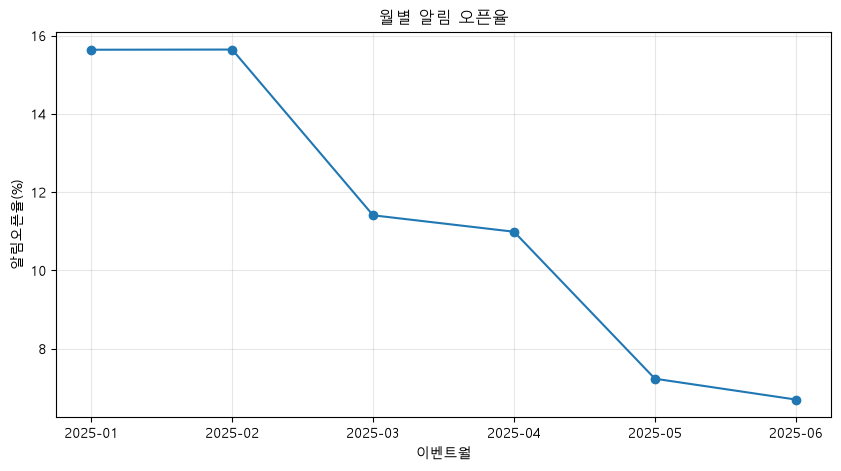

In [11]:
# 월별 알림수신/오픈 이벤트 수 및 오픈율 시각화

plt.figure(figsize=(10, 5))
plt.plot(alarm_by_month["event_month"], alarm_by_month["receive_events"], marker="o", label="알림수신")
plt.plot(alarm_by_month["event_month"], alarm_by_month["open_events"], marker="o", label="알림오픈")
plt.title("월별 알림수신/오픈 이벤트 수")
plt.xlabel("이벤트월")
plt.ylabel("이벤트 수")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(alarm_by_month["event_month"], alarm_by_month["event_open_rate"], marker="o")
plt.title("월별 알림 오픈율")
plt.xlabel("이벤트월")
plt.ylabel("알림오픈율(%)")
plt.grid(alpha=0.3)
plt.show()


알림발송량은 4월까지 증가했지만 알림 오픈율은 5,6월 하락 중.   
-> 알림의 양보다 알림 반응 효율이 악화되었을 가능성

In [12]:
# ============================================================
# 4. 로그 장애 기간 제외 후 월별 알림 패턴
# ============================================================

alarm_log_clean = alarm_log[~alarm_log["is_log_issue_period"]].copy()

alarm_by_month_clean = notification_summary(alarm_log_clean, ["event_month"])
alarm_by_month_clean = alarm_by_month_clean.sort_values("event_month")

display(alarm_by_month_clean)

event_type,event_month,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,10648,1665,1349,787,15.636739,58.339511
1,2025-02,32395,5067,3471,2236,15.641303,64.419476
2,2025-03,40918,4669,3164,2128,11.410626,67.256637
3,2025-04,49146,5399,3422,2345,10.985635,68.527177
4,2025-05,40457,2925,3226,1714,7.229898,53.130812
5,2025-06,18515,1240,1067,684,6.697272,64.104967


In [13]:
alarm_month_compare = alarm_by_month[
    ["event_month", "receive_events", "open_events", "event_open_rate"]
].rename(columns={
    "receive_events": "receive_events_all",
    "open_events": "open_events_all",
    "event_open_rate": "event_open_rate_all"
}).merge(
    alarm_by_month_clean[
        ["event_month", "receive_events", "open_events", "event_open_rate"]
    ].rename(columns={
        "receive_events": "receive_events_clean",
        "open_events": "open_events_clean",
        "event_open_rate": "event_open_rate_clean"
    }),
    on="event_month",
    how="outer"
)

display(alarm_month_compare)

event_type,event_month,receive_events_all,open_events_all,event_open_rate_all,receive_events_clean,open_events_clean,event_open_rate_clean
0,2025-01,10648,1665,15.636739,10648,1665,15.636739
1,2025-02,32395,5067,15.641303,32395,5067,15.641303
2,2025-03,43163,4923,11.405602,40918,4669,11.410626
3,2025-04,49146,5399,10.985635,49146,5399,10.985635
4,2025-05,40457,2925,7.229898,40457,2925,7.229898
5,2025-06,18515,1240,6.697272,18515,1240,6.697272


* 로그 장애가 알림-오픈에는 큰 영향을 미치지 않음

In [14]:
# ============================================================
# 5. 요일별 알림 오픈율
# ============================================================

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

alarm_by_weekday = notification_summary(alarm_log_clean, ["event_weekday"])

alarm_by_weekday["event_weekday"] = pd.Categorical(
    alarm_by_weekday["event_weekday"],
    categories=weekday_order,
    ordered=True
)

alarm_by_weekday = alarm_by_weekday.sort_values("event_weekday")

display(alarm_by_weekday)

event_type,event_weekday,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
3,월,27134,2941,5994,2091,10.838800,34.884885
6,화,26906,2986,5958,2120,11.097896,35.582410
2,수,26856,2957,5963,2117,11.010575,35.502264
1,목,26903,2955,5971,2097,10.983905,35.119745
0,금,27043,2952,5988,2105,10.915949,35.153641
5,토,28551,3115,6088,2179,10.910301,35.791721
4,일,28686,3059,6091,2158,10.663738,35.429322


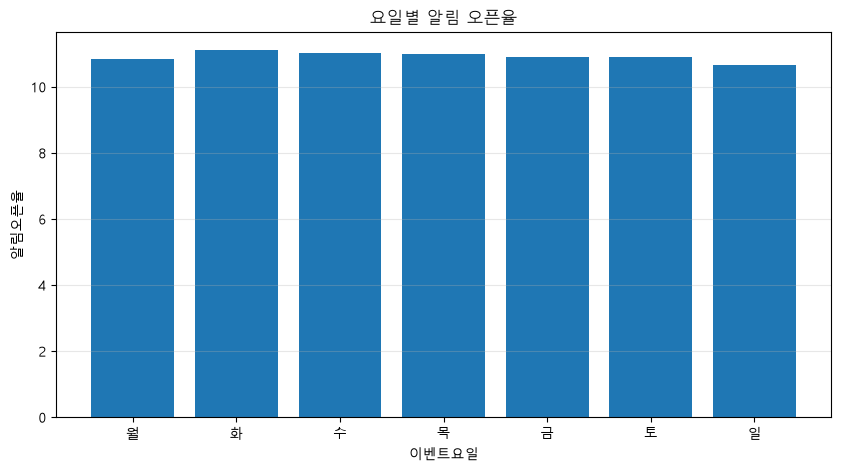

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(alarm_by_weekday["event_weekday"], alarm_by_weekday["event_open_rate"])
plt.title("요일별 알림 오픈율")
plt.xlabel("이벤트요일")
plt.ylabel("알림오픈율")
plt.grid(axis="y", alpha=0.3)
plt.show()

* 요일별 차이도 거의 없음

In [16]:
# ============================================================
# 6. 시간대별 알림 오픈율
# ============================================================

alarm_by_hour = notification_summary(alarm_log_clean, ["event_hour"])
alarm_by_hour = alarm_by_hour.sort_values("event_hour")

display(alarm_by_hour)

event_type,event_hour,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,7,13,0,13,0,0.000000,0.000000
1,8,14873,994,4408,861,6.683252,19.532668
2,9,14771,1596,4408,1286,10.804956,29.174229
3,10,14611,1592,4376,1292,10.895900,29.524680
4,11,14709,1627,4361,1301,11.061255,29.832607
5,12,14899,1607,4415,1278,10.785959,28.946772
6,13,14822,1674,4395,1342,11.294022,30.534699
7,14,14791,1582,4384,1261,10.695693,28.763686
8,15,14738,1667,4365,1351,11.310897,30.950745
9,16,14770,1627,4383,1300,11.015572,29.660050


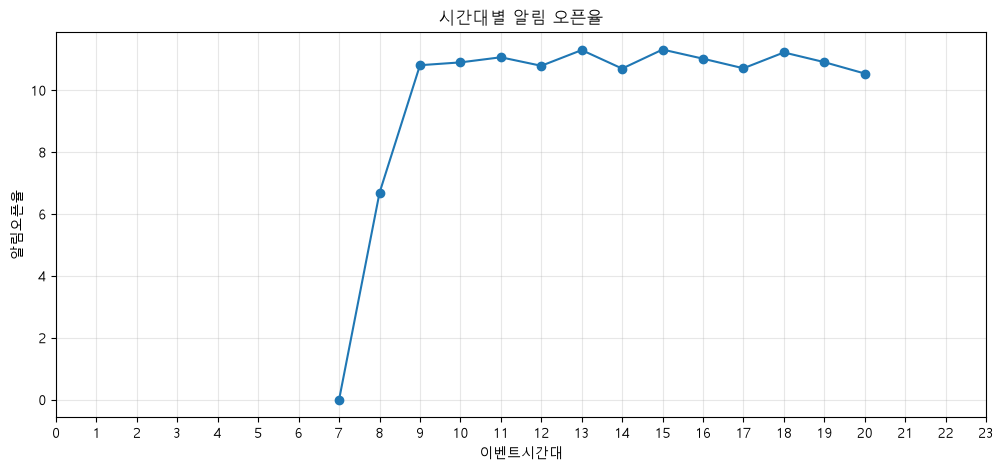

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(alarm_by_hour["event_hour"], alarm_by_hour["event_open_rate"], marker="o")
plt.title("시간대별 알림 오픈율")
plt.xlabel("이벤트시간대")
plt.ylabel("알림오픈율")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

In [18]:
display(alarm_by_hour[
        ["event_hour", "receive_events", "open_events", "event_open_rate"]
    ].sort_values("event_hour")
)

event_type,event_hour,receive_events,open_events,event_open_rate
0,7,13,0,0.000000
1,8,14873,994,6.683252
2,9,14771,1596,10.804956
3,10,14611,1592,10.895900
4,11,14709,1627,11.061255
5,12,14899,1607,10.785959
6,13,14822,1674,11.294022
7,14,14791,1582,10.695693
8,15,14738,1667,11.310897
9,16,14770,1627,11.015572


In [19]:
# ============================================================
# 알림수신/알림오픈 발생 시간 분포
# ============================================================

# 알림 이벤트만 사용
alarm_time_dist = (
    alarm_log_clean
    .groupby(["event_hour", "event_type"])
    .size()
    .unstack("event_type", fill_value=0)
    .reindex(range(24), fill_value=0)
    .reset_index()
)

# 필요한 컬럼이 없을 경우 대비
for col in ["알림수신", "알림오픈"]:
    if col not in alarm_time_dist.columns:
        alarm_time_dist[col] = 0

alarm_time_dist = alarm_time_dist.rename(columns={
    "알림수신": "receive_events",
    "알림오픈": "open_events"
})

# 전체 대비 비중 계산
alarm_time_dist["receive_ratio"] = (
    alarm_time_dist["receive_events"] / alarm_time_dist["receive_events"].sum()
)

alarm_time_dist["open_ratio"] = (
    alarm_time_dist["open_events"] / alarm_time_dist["open_events"].sum()
)

# 보기 좋게 퍼센트 컬럼 추가
alarm_time_dist["receive_ratio_pct"] = alarm_time_dist["receive_ratio"] * 100
alarm_time_dist["open_ratio_pct"] = alarm_time_dist["open_ratio"] * 100

display(alarm_time_dist)

event_type,event_hour,receive_events,open_events,receive_ratio,open_ratio,receive_ratio_pct,open_ratio_pct
0,0,0,0,0.000000,0.000000,0.000000,0.000000
1,1,0,0,0.000000,0.000000,0.000000,0.000000
2,2,0,0,0.000000,0.000000,0.000000,0.000000
3,3,0,0,0.000000,0.000000,0.000000,0.000000
4,4,0,0,0.000000,0.000000,0.000000,0.000000
5,5,0,0,0.000000,0.000000,0.000000,0.000000
6,6,0,0,0.000000,0.000000,0.000000,0.000000
7,7,13,0,0.000068,0.000000,0.006768,0.000000
8,8,14873,994,0.077432,0.047412,7.743168,4.741235
9,9,14771,1596,0.076901,0.076127,7.690065,7.612688


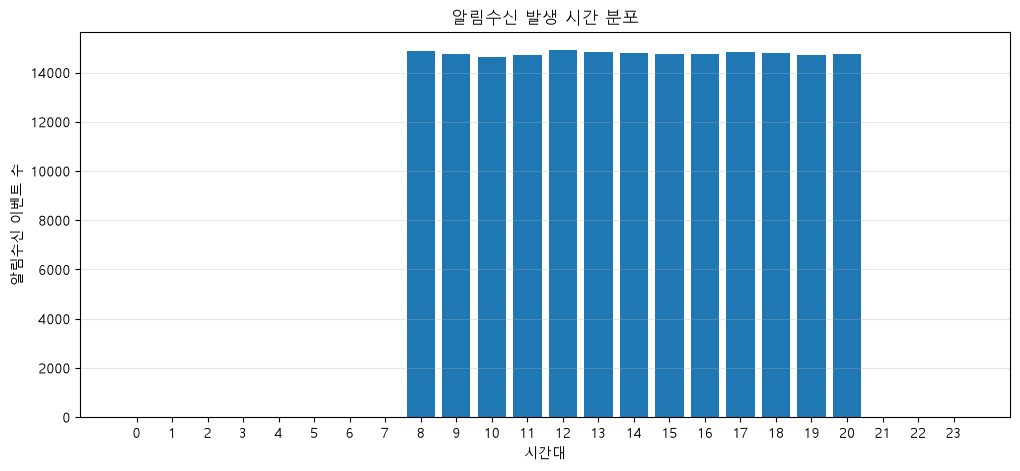

In [20]:
plt.figure(figsize=(12, 5))

plt.bar(
    alarm_time_dist["event_hour"],
    alarm_time_dist["receive_events"]
)

plt.title("알림수신 발생 시간 분포")
plt.xlabel("시간대")
plt.ylabel("알림수신 이벤트 수")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.show()

In [21]:
alarm_time_dist["open_minus_receive_ratio_pct"] = (
    alarm_time_dist["open_ratio_pct"] - alarm_time_dist["receive_ratio_pct"]
)

display(
    alarm_time_dist[
        [
            "event_hour",
            "receive_events",
            "open_events",
            "receive_ratio_pct",
            "open_ratio_pct",
            "open_minus_receive_ratio_pct"
        ]
    ].sort_values("event_hour")
)

event_type,event_hour,receive_events,open_events,receive_ratio_pct,open_ratio_pct,open_minus_receive_ratio_pct
0,0,0,0,0.000000,0.000000,0.000000
1,1,0,0,0.000000,0.000000,0.000000
2,2,0,0,0.000000,0.000000,0.000000
3,3,0,0,0.000000,0.000000,0.000000
4,4,0,0,0.000000,0.000000,0.000000
5,5,0,0,0.000000,0.000000,0.000000
6,6,0,0,0.000000,0.000000,0.000000
7,7,13,0,0.006768,0.000000,-0.006768
8,8,14873,994,7.743168,4.741235,-3.001933
9,9,14771,1596,7.690065,7.612688,-0.077377


In [22]:
top_receive_hours = (
    alarm_time_dist
    .sort_values("receive_events", ascending=False)
    [["event_hour", "receive_events", "receive_ratio_pct"]]
    .head(5)
)

top_open_hours = (
    alarm_time_dist
    .sort_values("open_events", ascending=False)
    [["event_hour", "open_events", "open_ratio_pct"]]
    .head(5)
)

print("[알림수신이 많은 시간대 Top 5]")
display(top_receive_hours)

print("[알림오픈이 많은 시간대 Top 5]")
display(top_open_hours)

[알림수신이 많은 시간대 Top 5]


event_type,event_hour,receive_events,receive_ratio_pct
12,12,14899,7.756704
8,8,14873,7.743168
17,17,14824,7.717658
13,13,14822,7.716617
18,18,14807,7.708807


[알림오픈이 많은 시간대 Top 5]


event_type,event_hour,open_events,open_ratio_pct
13,13,1674,7.984736
15,15,1667,7.951347
18,18,1661,7.922728
11,11,1627,7.760553
16,16,1627,7.760553


In [23]:
# ============================================================
# 8. 가입월 x 가입경로별 알림 반응
# ============================================================

alarm_by_signup_month_channel = notification_summary(
    alarm_log_clean,
    ["signup_month", "signup_channel"]
)

alarm_by_signup_month_channel = alarm_by_signup_month_channel.sort_values(
    ["signup_month", "signup_channel"]
)

display(alarm_by_signup_month_channel)

event_type,signup_month,signup_channel,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,오가닉,15057,2029,628,415,13.475460,66.082803
1,2025-01,퍼포먼스광고,16153,2189,718,465,13.551662,64.763231
2,2025-02,오가닉,38508,4550,1309,940,11.815727,71.810542
3,2025-02,퍼포먼스광고,46493,5418,1573,1130,11.653367,71.837254
4,2025-03,오가닉,13948,1387,544,336,9.944078,61.764706
5,2025-03,퍼포먼스광고,16051,1532,717,420,9.544577,58.577406
6,2025-04,오가닉,12035,1088,616,345,9.040299,56.006494
7,2025-04,퍼포먼스광고,15244,1326,752,447,8.698504,59.441489
8,2025-05,오가닉,7229,543,521,244,7.511412,46.833013
9,2025-05,퍼포먼스광고,9349,684,638,307,7.316291,48.119122


signup_channel,오가닉,퍼포먼스광고
signup_month,,
2025-01,13.475460,13.551662
2025-02,11.815727,11.653367
2025-03,9.944078,9.544577
2025-04,9.040299,8.698504
2025-05,7.511412,7.316291


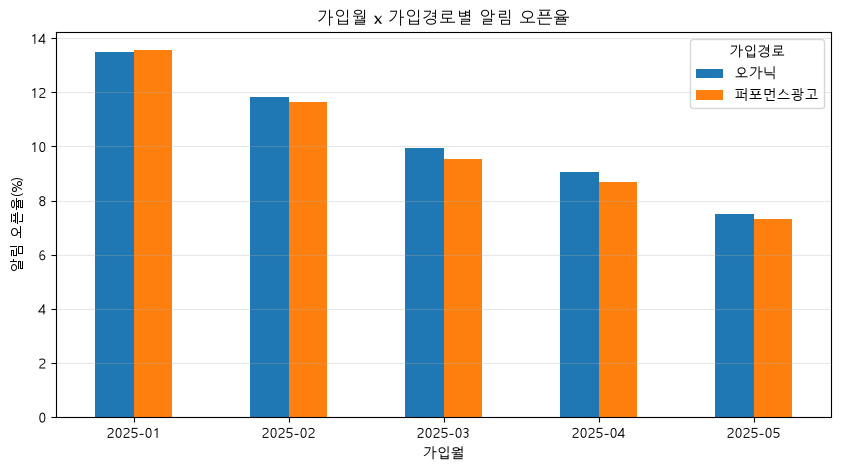

In [24]:
# 가입월 x 가입경로별 오픈율 피벗
alarm_channel_pivot = alarm_by_signup_month_channel.pivot_table(
    index="signup_month",
    columns="signup_channel",
    values="event_open_rate"
)

display(alarm_channel_pivot)

# 그래프
ax = alarm_channel_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)

plt.title("가입월 x 가입경로별 알림 오픈율")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="가입경로")
plt.show()

In [25]:
# 최근 가입자들은 가입 초반 30일 안에서도 알림 반응이 낮은지

# ============================================================
# 8-1. 이벤트 로그에 가입일자 붙이기
# ============================================================

# 날짜 타입 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")
user_df["signup_date"] = pd.to_datetime(user_df["signup_date"], errors="coerce")

# 가입월이 없으면 생성
if "signup_month" not in user_df.columns:
    user_df["signup_month"] = user_df["signup_date"].dt.to_period("M").astype(str)

# 가입경로 컬럼명 확인용
print(user_df.columns.tolist())

['user_id', 'signup_date', 'signup_channel', 'device', 'notification_agreed', 'notification_changed_date', 'signup_day', 'signup_month', 'signup_weekday', 'first_event_time', 'first_event_elapsed_hours', 'first_app_launch_time', 'app_launch_elapsed_hours', 'onboarding_completed_time', 'onboarding_elapsed_hours', 'app_launch_to_onboarding_hours', 'is_onboarding_completed', 'event_count_total', 'avg_events_per_session', 'is_signup_log_issue_period', 'is_no_event_user', 'is_notification_changed', 'is_first_event_before_signup']


In [26]:
# ============================================================
# 8-2. 가입 후 경과일 계산
# ============================================================

event_with_signup = event_df.merge(
    user_df[["user_id", "signup_date", "signup_month", "signup_channel"]],
    on="user_id",
    how="left"
)

event_with_signup["days_since_signup"] = (
    event_with_signup["event_time"].dt.normalize()
    - event_with_signup["signup_date"].dt.normalize()
).dt.days

display(
    event_with_signup[
        ["user_id", "event_time", "signup_date", "signup_month", "signup_channel", "days_since_signup", "event_type"]
    ].head()
)

,user_id,event_time,signup_date,signup_month,signup_channel,days_since_signup,event_type
0,U0000001,2025-01-25 07:25:45,2025-01-25,2025-01,오가닉,0,앱실행
1,U0000001,2025-01-25 07:26:15,2025-01-25,2025-01,오가닉,0,온보딩_완료
2,U0000001,2025-01-25 07:26:55,2025-01-25,2025-01,오가닉,0,챌린지_탐색
3,U0000001,2025-01-25 07:27:55,2025-01-25,2025-01,오가닉,0,챌린지참여
4,U0000001,2025-01-25 20:30:00,2025-01-25,2025-01,오가닉,0,알림수신


In [27]:
# ============================================================
# 8-3. 가입 후 30일 이내 알림 이벤트 추출
# ============================================================

notification_events = ["알림수신", "알림오픈"]

alarm_30d = event_with_signup[
    (event_with_signup["event_type"].isin(notification_events)) &
    (event_with_signup["days_since_signup"].between(0, 30))
].copy()

print("가입 후 30일 이내 알림 이벤트 수:", len(alarm_30d))
print("알림수신 수:", (alarm_30d["event_type"] == "알림수신").sum())
print("알림오픈 수:", (alarm_30d["event_type"] == "알림오픈").sum())

display(alarm_30d.head())

가입 후 30일 이내 알림 이벤트 수: 109851
알림수신 수: 97397
알림오픈 수: 12454


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_date,signup_month,signup_channel,days_since_signup
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,2025-01-25,2025-01,오가닉,0
9,U0000001,2025-01-26 15:18:00,알림수신,NaN,리마인드,2025-01-26,2025-01,일,15,False,False,2025-01-25,2025-01,오가닉,1
25,U0000001,2025-01-27 11:42:00,알림수신,NaN,광고성,2025-01-27,2025-01,월,11,False,False,2025-01-25,2025-01,오가닉,2
35,U0000001,2025-01-28 12:25:00,알림수신,NaN,리마인드,2025-01-28,2025-01,화,12,False,False,2025-01-25,2025-01,오가닉,3
48,U0000001,2025-01-29 18:23:00,알림수신,NaN,리마인드,2025-01-29,2025-01,수,18,False,False,2025-01-25,2025-01,오가닉,4


In [28]:
# ============================================================
# 8-4. 가입월별 가입 후 30일 이내 알림 오픈율
# ============================================================

alarm_30d_by_signup_month = notification_summary(
    alarm_30d,
    ["signup_month"]
)

alarm_30d_by_signup_month = alarm_30d_by_signup_month.sort_values("signup_month")

display(alarm_30d_by_signup_month)

event_type,signup_month,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,16195,2516,1363,886,15.535659,65.003668
1,2025-02,37885,5484,2915,2061,14.475386,70.703259
2,2025-03,14600,1790,1304,768,12.260274,58.895706
3,2025-04,15654,1661,1383,779,10.610707,56.326826
4,2025-05,13063,1003,1174,543,7.678175,46.252129


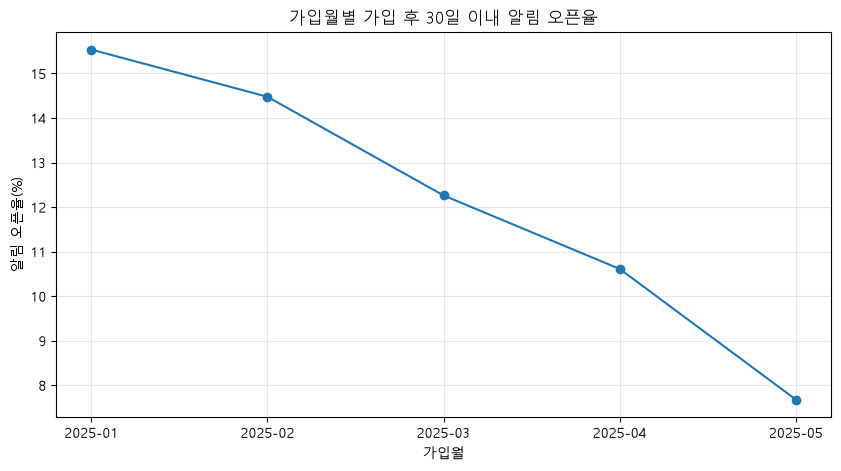

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    alarm_30d_by_signup_month["signup_month"],
    alarm_30d_by_signup_month["event_open_rate"],
    marker="o"
)

plt.title("가입월별 가입 후 30일 이내 알림 오픈율")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(alpha=0.3)
plt.show()

In [30]:
# ============================================================
# 8-5. 가입월 x 가입경로별 가입 후 30일 이내 알림 오픈율
# ============================================================

alarm_30d_by_month_channel = notification_summary(
    alarm_30d,
    ["signup_month", "signup_channel"]
)

alarm_30d_by_month_channel = alarm_30d_by_month_channel.sort_values(
    ["signup_month", "signup_channel"]
)

display(alarm_30d_by_month_channel)

event_type,signup_month,signup_channel,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,오가닉,7567,1186,628,412,15.673318,65.605096
1,2025-01,퍼포먼스광고,8453,1297,718,462,15.343665,64.345404
2,2025-02,오가닉,16945,2471,1310,929,14.582473,70.916031
3,2025-02,퍼포먼스광고,20538,2949,1573,1109,14.358750,70.502225
4,2025-03,오가닉,6554,817,558,336,12.465670,60.215054
5,2025-03,퍼포먼스광고,7960,964,738,426,12.110553,57.723577
6,2025-04,오가닉,6937,759,616,337,10.941329,54.707792
7,2025-04,퍼포먼스광고,8559,884,752,433,10.328309,57.579787
8,2025-05,오가닉,5623,431,521,235,7.664948,45.105566
9,2025-05,퍼포먼스광고,7223,558,638,300,7.725322,47.021944


signup_channel,오가닉,퍼포먼스광고
signup_month,,
2025-01,15.673318,15.343665
2025-02,14.582473,14.358750
2025-03,12.465670,12.110553
2025-04,10.941329,10.328309
2025-05,7.664948,7.725322


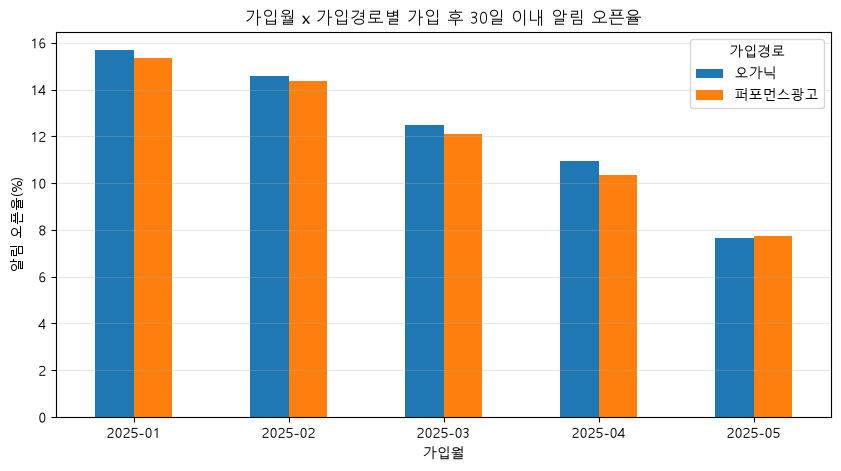

In [31]:
alarm_30d_pivot = alarm_30d_by_month_channel.pivot_table(
    index="signup_month",
    columns="signup_channel",
    values="event_open_rate"
)

display(alarm_30d_pivot)

ax = alarm_30d_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)

plt.title("가입월 x 가입경로별 가입 후 30일 이내 알림 오픈율")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="가입경로")
plt.show()

In [32]:
# ============================================================
# 8-6. 전체 기간 기준 vs 가입 후 30일 이내 기준 비교
# ============================================================

# 전체 기간 기준
alarm_all_by_signup_month = notification_summary(
    alarm_log_clean,
    ["signup_month"]
).sort_values("signup_month")

compare_alarm_open_rate = alarm_all_by_signup_month[
    ["signup_month", "receive_events", "open_events", "event_open_rate"]
].rename(columns={
    "receive_events": "all_receive_events",
    "open_events": "all_open_events",
    "event_open_rate": "all_event_open_rate"
}).merge(
    alarm_30d_by_signup_month[
        ["signup_month", "receive_events", "open_events", "event_open_rate"]
    ].rename(columns={
        "receive_events": "d30_receive_events",
        "open_events": "d30_open_events",
        "event_open_rate": "d30_event_open_rate"
    }),
    on="signup_month",
    how="outer"
)

display(compare_alarm_open_rate)

event_type,signup_month,all_receive_events,all_open_events,all_event_open_rate,d30_receive_events,d30_open_events,d30_event_open_rate
0,2025-01,31532,4264,13.522771,16195,2516,15.535659
1,2025-02,85925,10072,11.721850,37885,5484,14.475386
2,2025-03,30185,2940,9.739937,14600,1790,12.260274
3,2025-04,27574,2445,8.867049,15654,1661,10.610707
4,2025-05,16863,1244,7.377098,13063,1003,7.678175


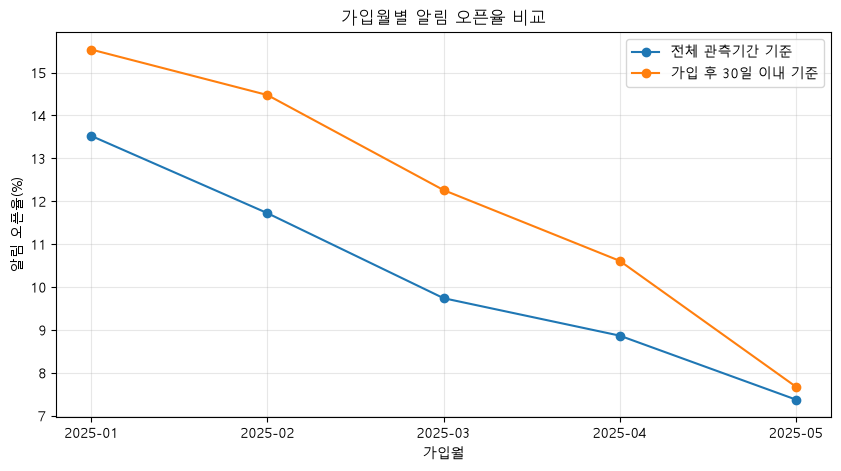

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    compare_alarm_open_rate["signup_month"],
    compare_alarm_open_rate["all_event_open_rate"],
    marker="o",
    label="전체 관측기간 기준"
)

plt.plot(
    compare_alarm_open_rate["signup_month"],
    compare_alarm_open_rate["d30_event_open_rate"],
    marker="o",
    label="가입 후 30일 이내 기준"
)

plt.title("가입월별 알림 오픈율 비교")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [34]:
# ============================================================
# 9. 유저별 알림 수신/오픈 빈도
# ============================================================

user_alarm = (
    alarm_log_clean
    .groupby(["user_id", "event_type"])
    .size()
    .unstack("event_type", fill_value=0)
    .reset_index()
)

for col in ["알림수신", "알림오픈"]:
    if col not in user_alarm.columns:
        user_alarm[col] = 0

user_alarm = user_alarm.rename(columns={
    "알림수신": "receive_events",
    "알림오픈": "open_events"
})

user_alarm["user_event_open_rate"] = np.where(
    user_alarm["receive_events"] > 0,
    user_alarm["open_events"] / user_alarm["receive_events"],
    np.nan
)

# 유저 프로필 붙이기
user_alarm = user_df[
    ["user_id", "signup_month", "signup_channel", "is_notification_changed", "is_onboarding_completed"]
].merge(
    user_alarm,
    on="user_id",
    how="left"
)

user_alarm[["receive_events", "open_events"]] = user_alarm[
    ["receive_events", "open_events"]
].fillna(0)

display(user_alarm.head())

,user_id,signup_month,signup_channel,is_notification_changed,is_onboarding_completed,receive_events,open_events,user_event_open_rate
0,U0000001,2025-01,오가닉,False,True,79.0,7.0,0.088608
1,U0000002,2025-05,오가닉,True,False,0.0,0.0,NaN
2,U0000003,2025-05,오가닉,False,False,0.0,0.0,NaN
3,U0000004,2025-02,퍼포먼스광고,False,False,18.0,1.0,0.055556
4,U0000005,2025-02,퍼포먼스광고,False,True,81.0,4.0,0.049383


In [35]:
# 알림 수신 횟수 구간화
bins = [-1, 0, 1, 3, 7, 14, 30, np.inf]
labels = ["0회", "1회", "2~3회", "4~7회", "8~14회", "15~30회", "31회+"]

user_alarm["receive_count_group"] = pd.cut(
    user_alarm["receive_events"],
    bins=bins,
    labels=labels
)

alarm_fatigue_summary = (
    user_alarm
    .groupby("receive_count_group", observed=False)
    .agg(
        users=("user_id", "nunique"),
        avg_receive_events=("receive_events", "mean"),
        avg_open_events=("open_events", "mean"),
        avg_open_rate=("user_event_open_rate", "mean"),
        median_open_rate=("user_event_open_rate", "median")
    )
    .reset_index()
)

display(alarm_fatigue_summary)

,receive_count_group,users,avg_receive_events,avg_open_events,avg_open_rate,median_open_rate
0,0회,4397,0.000000,0.000000,NaN,NaN
1,1회,1233,1.000000,0.126521,0.126521,0.000000
2,2~3회,1043,2.452541,0.315436,0.127197,0.000000
3,4~7회,1543,5.453014,0.730395,0.133373,0.142857
4,8~14회,1316,10.220365,1.262158,0.124025,0.111111
5,15~30회,501,19.946108,2.301397,0.116753,0.111111
6,31회+,2467,63.409404,6.704094,0.104573,0.101695


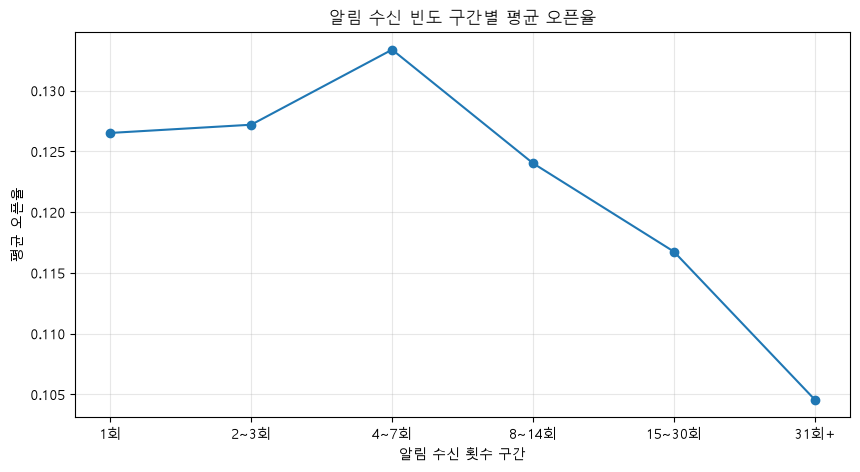

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(
    alarm_fatigue_summary["receive_count_group"].astype(str),
    alarm_fatigue_summary["avg_open_rate"],
    marker="o"
)
plt.title("알림 수신 빈도 구간별 평균 오픈율")
plt.xlabel("알림 수신 횟수 구간")
plt.ylabel("평균 오픈율")
plt.grid(alpha=0.3)
plt.show()

* 알림 피로도 가능성

8회 이상부터는 오픈율이 점진적으로 낮아짐. 추가 검증 필요   
가입월별로 나눠서 패턴 관측 필요

In [37]:
# ============================================================
# 11. 알림 수신 동의 변경 여부별 알림 반응
# ============================================================

alarm_by_notification_changed = (
    user_alarm
    .groupby("is_notification_changed")
    .agg(
        users=("user_id", "nunique"),
        avg_receive_events=("receive_events", "mean"),
        avg_open_events=("open_events", "mean"),
        avg_open_rate=("user_event_open_rate", "mean"),
        median_open_rate=("user_event_open_rate", "median")
    )
    .reset_index()
)

display(alarm_by_notification_changed)

,is_notification_changed,users,avg_receive_events,avg_open_events,avg_open_rate,median_open_rate
0,False,10524,16.841030,1.830103,0.118376,0.086420
1,True,1976,7.512146,0.862854,0.129864,0.050424


- true 그룹의 평균 오픈율이 더 높지만 중앙값은 더 낮음
    - -> 일부 고반응 유저가 평균 끌어올렸을 가능성


In [38]:
# ============================================================
# 12. 알림오픈 후 앱 내 행동 발생 여부
# ============================================================

# 알림오픈 이벤트
alarm_open_log = alarm_log_clean[
    alarm_log_clean["event_type"] == "알림오픈"
][["user_id", "event_time", "event_month", "event_weekday", "event_hour"]].copy()

alarm_open_log = alarm_open_log.rename(columns={
    "event_time": "alarm_open_time"
})

# 앱 내 행동 이벤트
# 알림수신/알림오픈은 앱 밖 또는 알림 관련 이벤트이므로 제외
app_behavior_log = event_df[
    ~event_df["event_type"].isin(notification_events)
].copy()

app_behavior_log = app_behavior_log[
    ["user_id", "event_time", "event_type", "session_id"]
].rename(columns={
    "event_time": "next_app_event_time",
    "event_type": "next_app_event_type",
    "session_id": "next_session_id"
})

# merge_asof 사용을 위한 정렬
alarm_open_log = alarm_open_log.sort_values("alarm_open_time")
app_behavior_log = app_behavior_log.sort_values("next_app_event_time")

# 알림오픈 이후 1시간 이내의 다음 앱 내 행동 찾기
after_open_1h = pd.merge_asof(
    alarm_open_log,
    app_behavior_log,
    left_on="alarm_open_time",
    right_on="next_app_event_time",
    by="user_id",
    direction="forward",
    tolerance=pd.Timedelta(hours=1)
)

after_open_1h["has_app_behavior_after_open_1h"] = after_open_1h["next_app_event_time"].notna()

display(after_open_1h.head())

,user_id,alarm_open_time,event_month,event_weekday,event_hour,next_app_event_time,next_app_event_type,next_session_id,has_app_behavior_after_open_1h
0,U0012166,2025-01-01 08:39:00,2025-01,수,8,NaT,NaN,NaN,False
1,U0003639,2025-01-01 09:21:00,2025-01,수,9,NaT,NaN,NaN,False
2,U0004574,2025-01-01 09:28:00,2025-01,수,9,NaT,NaN,NaN,False
3,U0006397,2025-01-01 12:00:00,2025-01,수,12,NaT,NaN,NaN,False
4,U0000645,2025-01-01 12:28:00,2025-01,수,12,NaT,NaN,NaN,False


- 알림오픈 수: 20,965건
- 1시간 내 앱 행동 발생 수: 3,096건
- 1시간 내 앱 행동 전환율: 14.77%
- -> 알림을 열었다고 해서 바로 앱 내 행동으로 이어지는 비율은 높지 않음



In [39]:
# 1시간 이내 앱 행동 전환율
open_to_app_1h_summary = pd.DataFrame({
    "알림오픈수": [len(after_open_1h)],
    "1시간내_앱행동발생수": [after_open_1h["has_app_behavior_after_open_1h"].sum()],
    "1시간내_앱행동전환율": [after_open_1h["has_app_behavior_after_open_1h"].mean()]
})

display(open_to_app_1h_summary)

,알림오픈수,1시간내_앱행동발생수,1시간내_앱행동전환율
0,20965,3096,0.147675


In [40]:
# 알림오픈 이후 24시간 이내의 다음 앱 내 행동 찾기
after_open_24h = pd.merge_asof(
    alarm_open_log,
    app_behavior_log,
    left_on="alarm_open_time",
    right_on="next_app_event_time",
    by="user_id",
    direction="forward",
    tolerance=pd.Timedelta(hours=24)
)

after_open_24h["has_app_behavior_after_open_24h"] = after_open_24h["next_app_event_time"].notna()

open_to_app_24h_summary = pd.DataFrame({
    "알림오픈수": [len(after_open_24h)],
    "24시간내_앱행동발생수": [after_open_24h["has_app_behavior_after_open_24h"].sum()],
    "24시간내_앱행동전환율": [after_open_24h["has_app_behavior_after_open_24h"].mean()]
})

display(open_to_app_24h_summary)

,알림오픈수,24시간내_앱행동발생수,24시간내_앱행동전환율
0,20965,18609,0.887622


In [41]:
# 알림오픈 후 1시간 이내 이어진 앱 행동 Top
next_behavior_1h = (
    after_open_1h[after_open_1h["has_app_behavior_after_open_1h"]]
    .groupby("next_app_event_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

next_behavior_1h["ratio"] = (
    next_behavior_1h["count"] / next_behavior_1h["count"].sum()
)

display(next_behavior_1h.head(20))

,next_app_event_type,count,ratio
3,앱실행,2979,0.977042
1,수면기록,22,0.007215
5,운동기록,16,0.005248
7,챌린지참여,9,0.002952
2,식단기록,7,0.002296
0,마음챙김,7,0.002296
6,챌린지_탐색,7,0.002296
4,온보딩_완료,2,0.000656


In [42]:
# ============================================================
# 13. 알림오픈 후 24시간 이내 이어진 앱 내 행동 Top
# ============================================================

next_behavior_after_open = (
    after_open_24h[after_open_24h["has_app_behavior_after_open_24h"]]
    .groupby("next_app_event_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

next_behavior_after_open["ratio"] = (
    next_behavior_after_open["count"] / next_behavior_after_open["count"].sum()
)

display(next_behavior_after_open.head(20))

,next_app_event_type,count,ratio
3,앱실행,18078,0.987761
1,수면기록,63,0.003442
5,운동기록,45,0.002459
0,마음챙김,42,0.002295
2,식단기록,28,0.001530
6,챌린지_탐색,25,0.001366
7,챌린지참여,18,0.000983
4,온보딩_완료,3,0.000164


- 알림오픈 수: 20,965건
- 24시간 내 앱 행동 발생 수: 18,609건
- 24시간 내 앱 행동 전환율: 88.76%
- 다만 알림이 앱 행동에 직접적 영향을 줬다고 속단하긴 어려움
    - 알림을 여는 유저 자체가 원래 활동성이 높은 유저일 수 있음

- 대부분 앱실행만 하고 나감

최근 가입자는 가입 직후부터 알림 반응이 낮은가,   
아니면 가입 후 며칠 지나서 알림 반응이 급격히 떨어지는가?

In [43]:
# ============================================================
# 1. 가입 후 경과일 구간 생성
# ============================================================

alarm_30d = alarm_30d.copy()

bins = [-1, 3, 7, 14, 30]
labels = ["D0~D3", "D4~D7", "D8~D14", "D15~D30"]

alarm_30d["signup_day_group"] = pd.cut(
    alarm_30d["days_since_signup"],
    bins=bins,
    labels=labels
)

# 확인
display(
    alarm_30d[
        ["user_id", "event_time", "signup_date", "signup_month", 
         "days_since_signup", "signup_day_group", "event_type"]
    ].head()
)

,user_id,event_time,signup_date,signup_month,days_since_signup,signup_day_group,event_type
4,U0000001,2025-01-25 20:30:00,2025-01-25,2025-01,0,D0~D3,알림수신
9,U0000001,2025-01-26 15:18:00,2025-01-25,2025-01,1,D0~D3,알림수신
25,U0000001,2025-01-27 11:42:00,2025-01-25,2025-01,2,D0~D3,알림수신
35,U0000001,2025-01-28 12:25:00,2025-01-25,2025-01,3,D0~D3,알림수신
48,U0000001,2025-01-29 18:23:00,2025-01-25,2025-01,4,D4~D7,알림수신


In [44]:
# ============================================================
# 2. 가입월 x 가입 후 경과일 구간별 알림 오픈율
# ============================================================

alarm_30d_by_month_daygroup = notification_summary(
    alarm_30d,
    ["signup_month", "signup_day_group"]
)

alarm_30d_by_month_daygroup["signup_day_group"] = pd.Categorical(
    alarm_30d_by_month_daygroup["signup_day_group"],
    categories=labels,
    ordered=True
)

alarm_30d_by_month_daygroup = alarm_30d_by_month_daygroup.sort_values(
    ["signup_month", "signup_day_group"]
)

display(alarm_30d_by_month_daygroup)

event_type,signup_month,signup_day_group,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,D0~D3,4475,703,1343,571,15.709497,42.516754
1,2025-01,D4~D7,3025,457,901,369,15.107438,40.954495
2,2025-01,D8~D14,3171,475,665,353,14.979502,53.082707
3,2025-01,D15~D30,5524,881,515,402,15.948588,78.058252
4,2025-02,D0~D3,9763,1576,2878,1258,16.142579,43.710910
5,2025-02,D4~D7,6996,1098,2064,914,15.694683,44.282946
6,2025-02,D8~D14,7617,1089,1620,797,14.296967,49.197531
7,2025-02,D15~D30,13509,1721,1348,941,12.739655,69.807122
8,2025-03,D0~D3,3845,481,1270,406,12.509753,31.968504
9,2025-03,D4~D7,2635,312,848,273,11.840607,32.193396


In [45]:
# ============================================================
# 3. 피벗 테이블
# ============================================================

alarm_30d_daygroup_pivot = alarm_30d_by_month_daygroup.pivot_table(
    index="signup_month",
    columns="signup_day_group",
    values="event_open_rate"
)

alarm_30d_daygroup_pivot = alarm_30d_daygroup_pivot[labels]

display(alarm_30d_daygroup_pivot)

signup_day_group,D0~D3,D4~D7,D8~D14,D15~D30
signup_month,,,,
2025-01,15.709497,15.107438,14.979502,15.948588
2025-02,16.142579,15.694683,14.296967,12.739655
2025-03,12.509753,11.840607,12.701682,12.041483
2025-04,11.921868,10.769750,11.018844,9.124731
2025-05,7.390964,7.195358,8.030888,8.031535


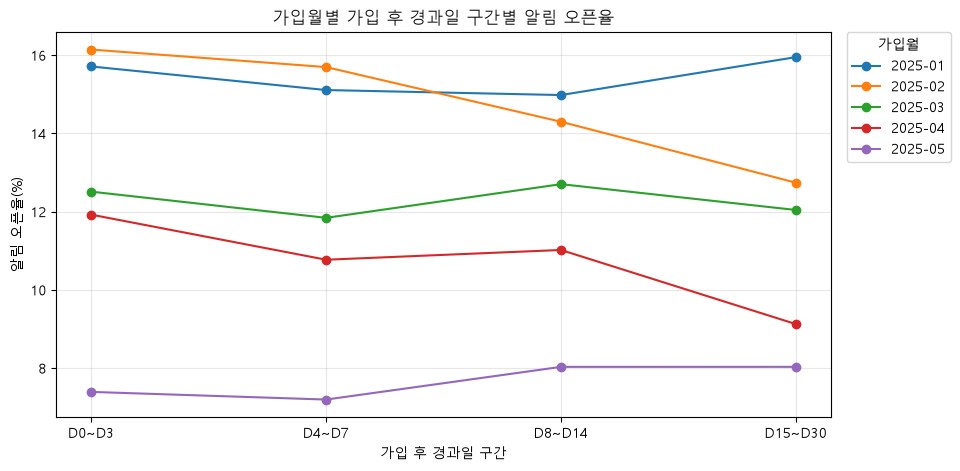

In [46]:
# ============================================================
# 4. 가입월별 경과일 구간 오픈율 라인 그래프
# ============================================================

plt.figure(figsize=(10, 5))

for month in alarm_30d_daygroup_pivot.index:
    plt.plot(
        alarm_30d_daygroup_pivot.columns.astype(str),
        alarm_30d_daygroup_pivot.loc[month],
        marker="o",
        label=month
    )

plt.title("가입월별 가입 후 경과일 구간별 알림 오픈율")
plt.xlabel("가입 후 경과일 구간")
plt.ylabel("알림 오픈율(%)")
plt.grid(alpha=0.3)
plt.legend(
    title="가입월",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
plt.show()

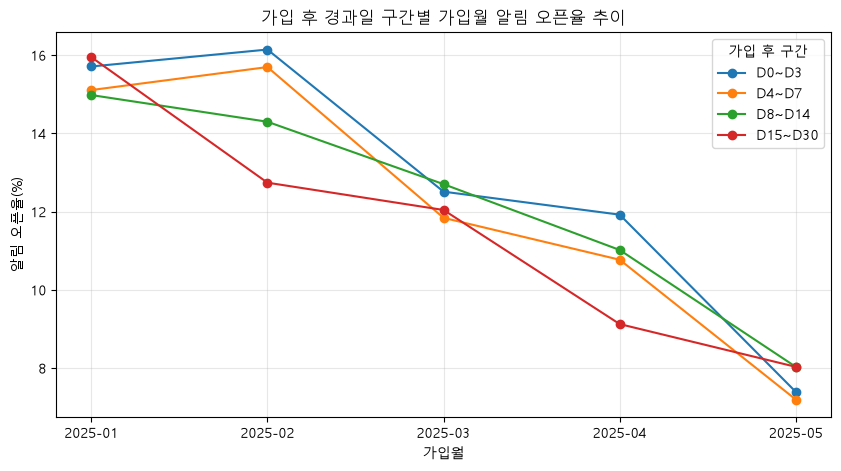

In [47]:
# ============================================================
# 5. 경과일 구간별 가입월 오픈율 추이
# ============================================================

plt.figure(figsize=(10, 5))

for day_group in labels:
    plt.plot(
        alarm_30d_daygroup_pivot.index,
        alarm_30d_daygroup_pivot[day_group],
        marker="o",
        label=day_group
    )

plt.title("가입 후 경과일 구간별 가입월 알림 오픈율 추이")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(alpha=0.3)
plt.legend(title="가입 후 구간")
plt.show()

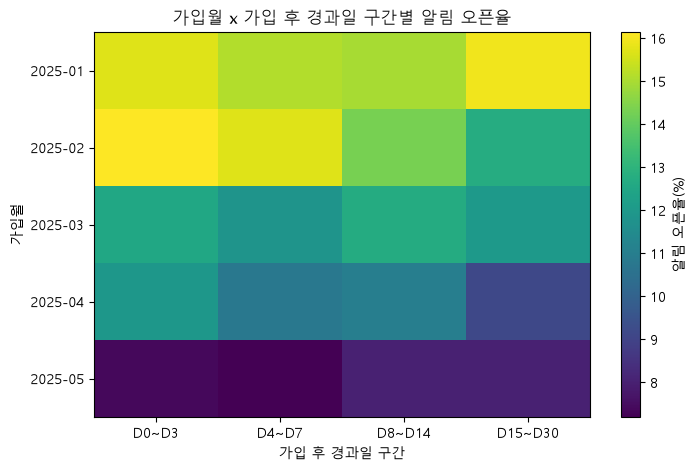

In [48]:
# ============================================================
# 6. 가입월 x 가입 후 경과일 구간 오픈율 히트맵
# ============================================================

plt.figure(figsize=(8, 5))

plt.imshow(alarm_30d_daygroup_pivot, aspect="auto")

plt.colorbar(label="알림 오픈율(%)")
plt.title("가입월 x 가입 후 경과일 구간별 알림 오픈율")
plt.xlabel("가입 후 경과일 구간")
plt.ylabel("가입월")

plt.xticks(
    range(len(alarm_30d_daygroup_pivot.columns)),
    alarm_30d_daygroup_pivot.columns
)

plt.yticks(
    range(len(alarm_30d_daygroup_pivot.index)),
    alarm_30d_daygroup_pivot.index
)

plt.show()

In [49]:
# 알림 관련 컬럼 후보 확인
[c for c in event_df.columns if "알림" in c or "alarm" in c or "notification" in c or "type" in c]

['event_type', 'notification_type', 'is_event_type_missing']

---
# 알림유형

In [50]:
# 알림 유형 값 확인

# 알림 이벤트만 추출
alarm_log_typed = event_df[
    event_df["event_type"].isin(notification_events)
].copy()

print("알림 이벤트 수:", len(alarm_log_typed))

print("\n[알림 유형 분포]")
display(
    alarm_log_typed["notification_type"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "notification_type", "notification_type": "count"})
)

print("\n[event_type x notification_type]")
display(
    alarm_log_typed
    .groupby(["event_type", "notification_type"], dropna=False)
    .size()
    .reset_index(name="event_count")
    .sort_values(["event_type", "event_count"], ascending=[True, False])
)

알림 이벤트 수: 215543

[알림 유형 분포]


,count,count
0,리마인드,84555
1,광고성,77059
2,챌린지_알림,53929



[event_type x notification_type]


,event_type,notification_type,event_count
0,알림수신,광고성,74958
1,알림수신,리마인드,73667
2,알림수신,챌린지_알림,45699
4,알림오픈,리마인드,10888
5,알림오픈,챌린지_알림,8230
3,알림오픈,광고성,2101


In [51]:
# 알림 유형별 오픈율
alarm_by_type = notification_summary(
    alarm_log_typed,
    ["notification_type"]
)

alarm_by_type = alarm_by_type.sort_values(
    "event_open_rate",
    ascending=False
).reset_index(drop=True)

display(alarm_by_type)

event_type,notification_type,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,챌린지_알림,45699,8230,6228,3657,18.009147,58.718690
1,리마인드,73667,10888,7008,4010,14.780024,57.220320
2,광고성,74958,2101,6064,1575,2.802903,25.972955


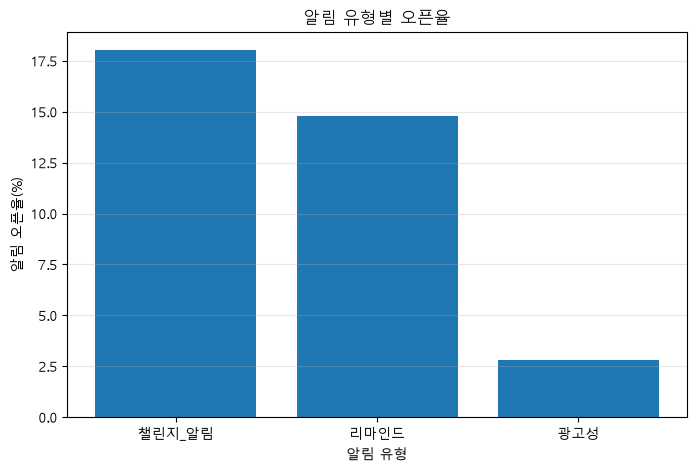

In [52]:
plt.figure(figsize=(8, 5))

plt.bar(
    alarm_by_type["notification_type"].astype(str),
    alarm_by_type["event_open_rate"]
)

plt.title("알림 유형별 오픈율")
plt.xlabel("알림 유형")
plt.ylabel("알림 오픈율(%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [53]:
# 월별 x 알림 유형별 오픈율
alarm_by_month_type = notification_summary(
    alarm_log_typed,
    ["event_month", "notification_type"]
)

alarm_by_month_type = alarm_by_month_type.sort_values(
    ["event_month", "notification_type"]
).reset_index(drop=True)

display(alarm_by_month_type)

event_type,event_month,notification_type,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,광고성,1066,27,602,27,2.532833,4.485050
1,2025-01,리마인드,5868,904,1200,560,15.405590,46.666667
2,2025-01,챌린지_알림,3714,734,1078,499,19.763059,46.289425
3,2025-02,광고성,3302,96,1843,94,2.907329,5.100380
4,2025-02,리마인드,17736,2772,3123,1627,15.629229,52.097342
5,2025-02,챌린지_알림,11357,2199,2818,1455,19.362508,51.632363
6,2025-03,광고성,15056,460,2817,429,3.055260,15.228967
7,2025-03,리마인드,17278,2560,2893,1581,14.816530,54.649153
8,2025-03,챌린지_알림,10829,1903,2651,1330,17.573183,50.169747
9,2025-04,광고성,17210,489,3047,450,2.841371,14.768625


In [54]:
alarm_month_type_pivot = alarm_by_month_type.pivot_table(
    index="event_month",
    columns="notification_type",
    values="event_open_rate"
)

display(alarm_month_type_pivot)

notification_type,광고성,리마인드,챌린지_알림
event_month,,,
2025-01,2.532833,15.405590,19.763059
2025-02,2.907329,15.629229,19.362508
2025-03,3.055260,14.816530,17.573183
2025-04,2.841371,14.245867,17.195940
2025-05,2.718196,14.524076,17.585808
2025-06,2.612034,13.197970,15.908142


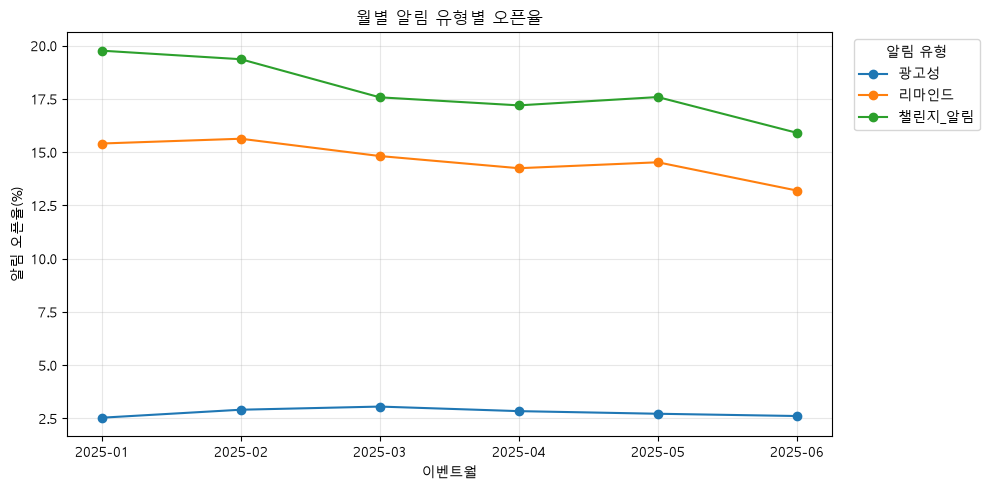

In [55]:
plt.figure(figsize=(10, 5))

for col in alarm_month_type_pivot.columns:
    plt.plot(
        alarm_month_type_pivot.index,
        alarm_month_type_pivot[col],
        marker="o",
        label=col
    )

plt.title("월별 알림 유형별 오픈율")
plt.xlabel("이벤트월")
plt.ylabel("알림 오픈율(%)")
plt.grid(alpha=0.3)
plt.legend(
    title="알림 유형",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [56]:
# 가입 후 30일 이내 알림 유형별 오픈율

# user_df 날짜 타입 보정
user_df["signup_date"] = pd.to_datetime(user_df["signup_date"], errors="coerce")

if "signup_month" not in user_df.columns:
    user_df["signup_month"] = user_df["signup_date"].dt.to_period("M").astype(str)

# 이벤트에 가입정보 붙이기
event_with_signup = event_df.merge(
    user_df[["user_id", "signup_date", "signup_month", "signup_channel"]],
    on="user_id",
    how="left"
)

event_with_signup["days_since_signup"] = (
    event_with_signup["event_time"].dt.normalize()
    - event_with_signup["signup_date"].dt.normalize()
).dt.days

In [57]:
alarm_30d_typed = event_with_signup[
    (event_with_signup["event_type"].isin(notification_events)) &
    (event_with_signup["days_since_signup"].between(0, 30))
].copy()

print("가입 후 30일 이내 알림 이벤트 수:", len(alarm_30d_typed))
display(alarm_30d_typed.head())

가입 후 30일 이내 알림 이벤트 수: 109851


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_date,signup_month,signup_channel,days_since_signup
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,2025-01-25,2025-01,오가닉,0
9,U0000001,2025-01-26 15:18:00,알림수신,NaN,리마인드,2025-01-26,2025-01,일,15,False,False,2025-01-25,2025-01,오가닉,1
25,U0000001,2025-01-27 11:42:00,알림수신,NaN,광고성,2025-01-27,2025-01,월,11,False,False,2025-01-25,2025-01,오가닉,2
35,U0000001,2025-01-28 12:25:00,알림수신,NaN,리마인드,2025-01-28,2025-01,화,12,False,False,2025-01-25,2025-01,오가닉,3
48,U0000001,2025-01-29 18:23:00,알림수신,NaN,리마인드,2025-01-29,2025-01,수,18,False,False,2025-01-25,2025-01,오가닉,4


In [58]:
alarm_30d_by_type = notification_summary(
    alarm_30d_typed,
    ["notification_type"]
)

alarm_30d_by_type = alarm_30d_by_type.sort_values(
    "event_open_rate",
    ascending=False
).reset_index(drop=True)

display(alarm_30d_by_type)

event_type,notification_type,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,챌린지_알림,25944,5033,6219,3226,19.399476,51.873292
1,리마인드,41458,6485,7007,3669,15.642337,52.361924
2,광고성,29995,936,6037,828,3.120520,13.715422


In [59]:
alarm_30d_by_month_type = notification_summary(
    alarm_30d_typed,
    ["signup_month", "notification_type"]
)

alarm_30d_by_month_type = alarm_30d_by_month_type.sort_values(
    ["signup_month", "notification_type"]
).reset_index(drop=True)

display(alarm_30d_by_month_type)

event_type,signup_month,notification_type,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,광고성,1677,37,746,36,2.206321,4.825737
1,2025-01,리마인드,8911,1390,1226,690,15.598698,56.280587
2,2025-01,챌린지_알림,5607,1089,1127,626,19.422151,55.545697
3,2025-02,광고성,7527,266,1953,249,3.533944,12.749616
4,2025-02,리마인드,18552,2903,2672,1582,15.647909,59.206587
5,2025-02,챌린지_알림,11806,2315,2435,1411,19.608674,57.946612
6,2025-03,광고성,5110,161,1070,150,3.150685,14.018692
7,2025-03,리마인드,5808,935,1112,542,16.098485,48.741007
8,2025-03,챌린지_알림,3682,694,971,482,18.848452,49.639547
9,2025-04,광고성,7191,208,1164,172,2.892505,14.776632


notification_type,광고성,리마인드,챌린지_알림
signup_month,,,
2025-01,2.206321,15.598698,19.422151
2025-02,3.533944,15.647909,19.608674
2025-03,3.150685,16.098485,18.848452
2025-04,2.892505,15.743879,19.568665
2025-05,3.109541,14.633299,18.750000


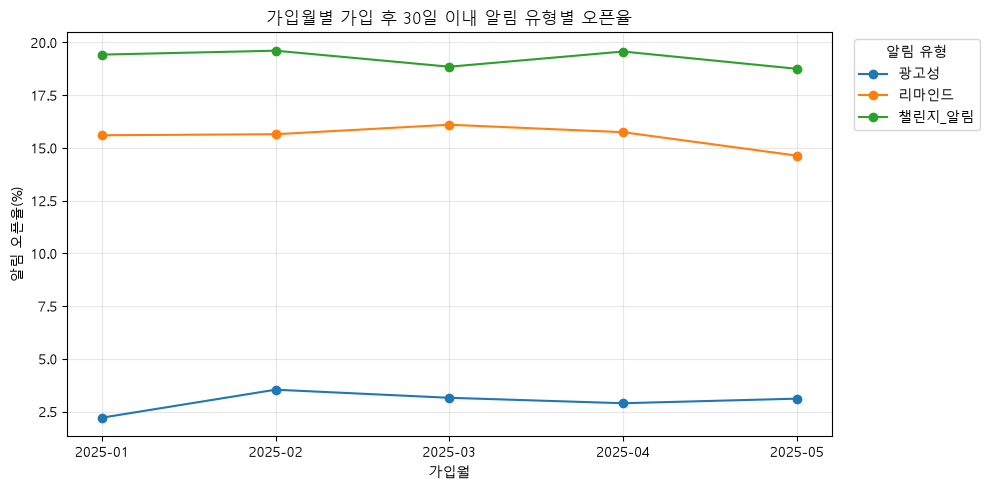

In [60]:
alarm_30d_type_pivot = alarm_30d_by_month_type.pivot_table(
    index="signup_month",
    columns="notification_type",
    values="event_open_rate"
)

display(alarm_30d_type_pivot)

plt.figure(figsize=(10, 5))

for col in alarm_30d_type_pivot.columns:
    plt.plot(
        alarm_30d_type_pivot.index,
        alarm_30d_type_pivot[col],
        marker="o",
        label=col
    )

plt.title("가입월별 가입 후 30일 이내 알림 유형별 오픈율")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(alpha=0.3)
plt.legend(
    title="알림 유형",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# 가입 후 30일 이내: 가입월별 알림 유형 수신 구성비
# ============================================================

alarm_30d_receive_mix = (
    alarm_30d_typed[alarm_30d_typed["event_type"] == "알림수신"]
    .groupby(["signup_month", "notification_type"])
    .size()
    .reset_index(name="receive_events")
)

alarm_30d_receive_mix["receive_ratio"] = (
    alarm_30d_receive_mix["receive_events"]
    / alarm_30d_receive_mix.groupby("signup_month")["receive_events"].transform("sum")
    * 100
)

display(alarm_30d_receive_mix)

,signup_month,notification_type,receive_events,receive_ratio
0,2025-01,광고성,1677,10.355048
1,2025-01,리마인드,8911,55.023155
2,2025-01,챌린지_알림,5607,34.621797
3,2025-02,광고성,7527,19.868022
4,2025-02,리마인드,18552,48.969249
5,2025-02,챌린지_알림,11806,31.162729
6,2025-03,광고성,5110,35.000000
7,2025-03,리마인드,5808,39.780822
8,2025-03,챌린지_알림,3682,25.219178
9,2025-04,광고성,7191,45.937141


notification_type,광고성,리마인드,챌린지_알림
signup_month,,,
2025-01,10.355048,55.023155,34.621797
2025-02,19.868022,48.969249,31.162729
2025-03,35.000000,39.780822,25.219178
2025-04,45.937141,33.921043,20.141817
2025-05,64.992728,22.024037,12.983235


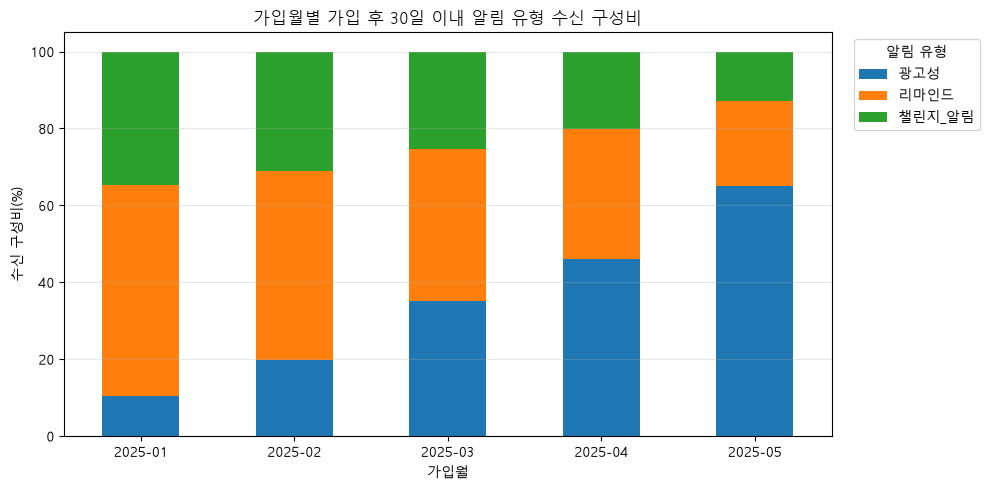

In [72]:
receive_mix_pivot = alarm_30d_receive_mix.pivot_table(
    index="signup_month",
    columns="notification_type",
    values="receive_ratio",
    fill_value=0
)

display(receive_mix_pivot)

ax = receive_mix_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    rot=0
)

plt.title("가입월별 가입 후 30일 이내 알림 유형 수신 구성비")
plt.xlabel("가입월")
plt.ylabel("수신 구성비(%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="알림 유형", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
challenge_event_types = sorted([
    x for x in event_df["event_type"].dropna().unique()
    if "챌린지" in x
])

challenge_event_types

['챌린지_탐색', '챌린지참여']

In [62]:
# 챌린지 알림 오픈 후 챌린지 행동 전환

challenge_alarm_label = "챌린지_알림"
challenge_behavior_events = ["챌린지_탐색", "챌린지참여"]

# 챌린지 알림 오픈 로그
challenge_alarm_open = event_with_signup[
    (event_with_signup["event_type"] == "알림오픈") &
    (event_with_signup["notification_type"] == challenge_alarm_label)
][
    ["user_id", "event_time", "signup_month", "signup_channel"]
].copy()

challenge_alarm_open = challenge_alarm_open.rename(columns={
    "event_time": "challenge_alarm_open_time"
})

# 챌린지 행동 로그
challenge_behavior_log = event_with_signup[
    event_with_signup["event_type"].isin(challenge_behavior_events)
][
    ["user_id", "event_time", "event_type", "session_id"]
].copy()

challenge_behavior_log = challenge_behavior_log.rename(columns={
    "event_time": "next_challenge_event_time",
    "event_type": "next_challenge_event_type",
    "session_id": "next_challenge_session_id"
})

# merge_asof용 정렬
challenge_alarm_open = challenge_alarm_open.sort_values("challenge_alarm_open_time")
challenge_behavior_log = challenge_behavior_log.sort_values("next_challenge_event_time")

In [63]:
# 1시간 이내 전혼

after_challenge_open_1h = pd.merge_asof(
    challenge_alarm_open,
    challenge_behavior_log,
    left_on="challenge_alarm_open_time",
    right_on="next_challenge_event_time",
    by="user_id",
    direction="forward",
    tolerance=pd.Timedelta(hours=1)
)

after_challenge_open_1h["has_challenge_behavior_1h"] = (
    after_challenge_open_1h["next_challenge_event_time"].notna()
)

challenge_open_1h_summary = pd.DataFrame({
    "챌린지알림오픈수": [len(after_challenge_open_1h)],
    "1시간내_챌린지행동수": [after_challenge_open_1h["has_challenge_behavior_1h"].sum()],
    "1시간내_챌린지행동전환율": [after_challenge_open_1h["has_challenge_behavior_1h"].mean() * 100]
})

display(challenge_open_1h_summary)

,챌린지알림오픈수,1시간내_챌린지행동수,1시간내_챌린지행동전환율
0,8230,173,2.102066


In [64]:
# 24시간 이내

after_challenge_open_24h = pd.merge_asof(
    challenge_alarm_open,
    challenge_behavior_log,
    left_on="challenge_alarm_open_time",
    right_on="next_challenge_event_time",
    by="user_id",
    direction="forward",
    tolerance=pd.Timedelta(hours=24)
)

after_challenge_open_24h["has_challenge_behavior_24h"] = (
    after_challenge_open_24h["next_challenge_event_time"].notna()
)

challenge_open_24h_summary = pd.DataFrame({
    "챌린지알림오픈수": [len(after_challenge_open_24h)],
    "24시간내_챌린지행동수": [after_challenge_open_24h["has_challenge_behavior_24h"].sum()],
    "24시간내_챌린지행동전환율": [after_challenge_open_24h["has_challenge_behavior_24h"].mean() * 100]
})

display(challenge_open_24h_summary)

,챌린지알림오픈수,24시간내_챌린지행동수,24시간내_챌린지행동전환율
0,8230,1770,21.506683


In [73]:
# ============================================================
# 챌린지 알림 오픈 이전 챌린지 행동 여부 확인
# ============================================================

challenge_behavior_events = ["챌린지_탐색", "챌린지참여"]

# 유저별 첫 챌린지 알림 오픈 시간
first_challenge_alarm_open = (
    event_30d[
        (event_30d["event_type"] == "알림오픈") &
        (event_30d["notification_type"] == "챌린지_알림")
    ]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_challenge_alarm_open_time")
)

# 유저별 첫 챌린지 행동 시간
first_challenge_behavior = (
    event_30d[
        event_30d["event_type"].isin(challenge_behavior_events)
    ]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_challenge_behavior_time")
)

challenge_temporal = user_df[["user_id", "signup_month", "signup_channel"]].merge(
    first_challenge_alarm_open,
    on="user_id",
    how="left"
).merge(
    first_challenge_behavior,
    on="user_id",
    how="left"
)

challenge_temporal["has_challenge_alarm_open"] = (
    challenge_temporal["first_challenge_alarm_open_time"].notna()
)

challenge_temporal["has_challenge_behavior"] = (
    challenge_temporal["first_challenge_behavior_time"].notna()
)

challenge_temporal["challenge_behavior_after_alarm_open"] = (
    challenge_temporal["has_challenge_alarm_open"] &
    challenge_temporal["has_challenge_behavior"] &
    (
        challenge_temporal["first_challenge_behavior_time"]
        > challenge_temporal["first_challenge_alarm_open_time"]
    )
)

challenge_temporal["challenge_behavior_before_alarm_open"] = (
    challenge_temporal["has_challenge_alarm_open"] &
    challenge_temporal["has_challenge_behavior"] &
    (
        challenge_temporal["first_challenge_behavior_time"]
        < challenge_temporal["first_challenge_alarm_open_time"]
    )
)

display(challenge_temporal.head())

,user_id,signup_month,signup_channel,first_challenge_alarm_open_time,first_challenge_behavior_time,has_challenge_alarm_open,has_challenge_behavior,challenge_behavior_after_alarm_open,challenge_behavior_before_alarm_open
0,U0000001,2025-01,오가닉,2025-02-21 12:59:00,2025-01-25 07:26:55,True,True,False,True
1,U0000002,2025-05,오가닉,NaT,2025-05-06 16:23:42,False,True,False,False
2,U0000003,2025-05,오가닉,NaT,NaT,False,False,False,False
3,U0000004,2025-02,퍼포먼스광고,2025-02-25 11:03:00,2025-03-03 17:26:28,True,True,True,False
4,U0000005,2025-02,퍼포먼스광고,NaT,2025-02-18 12:50:01,False,True,False,False


In [74]:
challenge_temporal_summary = pd.DataFrame({
    "챌린지알림오픈유저수": [challenge_temporal["has_challenge_alarm_open"].sum()],
    "오픈전_이미챌린지행동유저수": [challenge_temporal["challenge_behavior_before_alarm_open"].sum()],
    "오픈후_첫챌린지행동유저수": [challenge_temporal["challenge_behavior_after_alarm_open"].sum()]
})

challenge_temporal_summary["오픈전_이미행동비율"] = (
    challenge_temporal_summary["오픈전_이미챌린지행동유저수"]
    / challenge_temporal_summary["챌린지알림오픈유저수"]
    * 100
)

challenge_temporal_summary["오픈후_첫행동비율"] = (
    challenge_temporal_summary["오픈후_첫챌린지행동유저수"]
    / challenge_temporal_summary["챌린지알림오픈유저수"]
    * 100
)

display(challenge_temporal_summary)

,챌린지알림오픈유저수,오픈전_이미챌린지행동유저수,오픈후_첫챌린지행동유저수,오픈전_이미행동비율,오픈후_첫행동비율
0,3226,2277,518,70.582765,16.057037


In [65]:
# 유저 단위 - 챌린지 알림 그룹별 챌린지 참여율

# 가입 후 30일 이내 전체 이벤트
event_30d = event_with_signup[
    event_with_signup["days_since_signup"].between(0, 30)
].copy()

# 유저별 챌린지 알림 수신/오픈 수
challenge_alarm_user = (
    event_30d[
        (event_30d["notification_type"] == "챌린지_알림") &
        (event_30d["event_type"].isin(["알림수신", "알림오픈"]))
    ]
    .groupby("user_id")
    .agg(
        challenge_alarm_receive_cnt=(
            "event_type",
            lambda x: (x == "알림수신").sum()
        ),
        challenge_alarm_open_cnt=(
            "event_type",
            lambda x: (x == "알림오픈").sum()
        )
    )
    .reset_index()
)

# 유저별 챌린지 행동 수
challenge_behavior_user = (
    event_30d[
        event_30d["event_type"].isin(challenge_behavior_events)
    ]
    .groupby("user_id")
    .agg(
        challenge_behavior_cnt=("event_type", "count"),
        challenge_participation_cnt=(
            "event_type",
            lambda x: (x == "챌린지참여").sum()
        ),
        challenge_explore_cnt=(
            "event_type",
            lambda x: (x == "챌린지_탐색").sum()
        )
    )
    .reset_index()
)

In [66]:
challenge_user_base = user_df[
    ["user_id", "signup_month", "signup_channel"]
].copy()

challenge_user_base = challenge_user_base.merge(
    challenge_alarm_user,
    on="user_id",
    how="left"
).merge(
    challenge_behavior_user,
    on="user_id",
    how="left"
)

fill_cols = [
    "challenge_alarm_receive_cnt",
    "challenge_alarm_open_cnt",
    "challenge_behavior_cnt",
    "challenge_participation_cnt",
    "challenge_explore_cnt"
]

challenge_user_base[fill_cols] = challenge_user_base[fill_cols].fillna(0)

challenge_user_base["has_challenge_alarm_receive"] = (
    challenge_user_base["challenge_alarm_receive_cnt"] > 0
)

challenge_user_base["has_challenge_alarm_open"] = (
    challenge_user_base["challenge_alarm_open_cnt"] > 0
)

challenge_user_base["has_challenge_behavior"] = (
    challenge_user_base["challenge_behavior_cnt"] > 0
)

challenge_user_base["has_challenge_participation"] = (
    challenge_user_base["challenge_participation_cnt"] > 0
)

def make_challenge_alarm_group(row):
    if row["has_challenge_alarm_open"]:
        return "챌린지알림_오픈"
    elif row["has_challenge_alarm_receive"]:
        return "챌린지알림_수신만"
    else:
        return "챌린지알림_미수신"

challenge_user_base["challenge_alarm_group"] = challenge_user_base.apply(
    make_challenge_alarm_group,
    axis=1
)

display(challenge_user_base.head())

,user_id,signup_month,signup_channel,challenge_alarm_receive_cnt,challenge_alarm_open_cnt,challenge_behavior_cnt,challenge_participation_cnt,challenge_explore_cnt,has_challenge_alarm_receive,has_challenge_alarm_open,has_challenge_behavior,has_challenge_participation,challenge_alarm_group
0,U0000001,2025-01,오가닉,10.0,2.0,45.0,25.0,20.0,True,True,True,True,챌린지알림_오픈
1,U0000002,2025-05,오가닉,0.0,0.0,18.0,10.0,8.0,False,False,True,True,챌린지알림_미수신
2,U0000003,2025-05,오가닉,0.0,0.0,0.0,0.0,0.0,False,False,False,False,챌린지알림_미수신
3,U0000004,2025-02,퍼포먼스광고,6.0,1.0,4.0,2.0,2.0,True,True,True,True,챌린지알림_오픈
4,U0000005,2025-02,퍼포먼스광고,8.0,0.0,11.0,6.0,5.0,True,False,True,True,챌린지알림_수신만


In [67]:
challenge_alarm_group_summary = (
    challenge_user_base
    .groupby("challenge_alarm_group")
    .agg(
        users=("user_id", "nunique"),
        challenge_behavior_users=("has_challenge_behavior", "sum"),
        challenge_participation_users=("has_challenge_participation", "sum"),
        avg_challenge_behavior_cnt=("challenge_behavior_cnt", "mean"),
        avg_challenge_participation_cnt=("challenge_participation_cnt", "mean")
    )
    .reset_index()
)

challenge_alarm_group_summary["challenge_behavior_rate"] = (
    challenge_alarm_group_summary["challenge_behavior_users"] /
    challenge_alarm_group_summary["users"] * 100
)

challenge_alarm_group_summary["challenge_participation_rate"] = (
    challenge_alarm_group_summary["challenge_participation_users"] /
    challenge_alarm_group_summary["users"] * 100
)

display(challenge_alarm_group_summary)

,challenge_alarm_group,users,challenge_behavior_users,challenge_participation_users,avg_challenge_behavior_cnt,avg_challenge_participation_cnt,challenge_behavior_rate,challenge_participation_rate
0,챌린지알림_미수신,6274,4319,4307,8.503666,4.695888,68.839656,68.648390
1,챌린지알림_수신만,3000,2182,2174,9.537333,5.271667,72.733333,72.466667
2,챌린지알림_오픈,3226,2795,2791,15.666770,8.668630,86.639802,86.515809


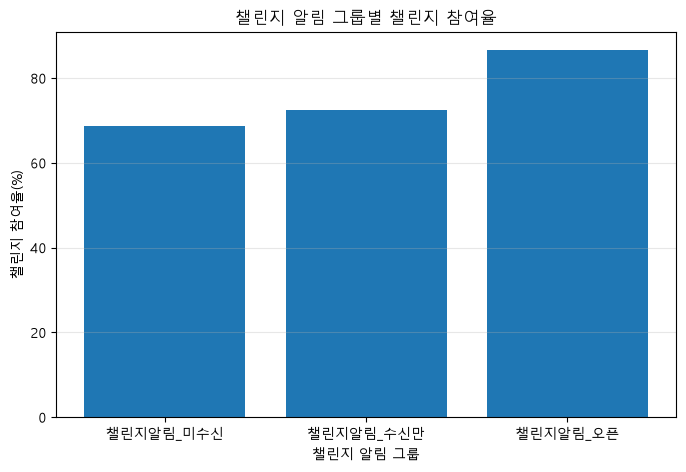

In [68]:
group_order = ["챌린지알림_미수신", "챌린지알림_수신만", "챌린지알림_오픈"]

plot_df = challenge_alarm_group_summary.set_index("challenge_alarm_group").reindex(group_order).reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["challenge_alarm_group"],
    plot_df["challenge_participation_rate"]
)

plt.title("챌린지 알림 그룹별 챌린지 참여율")
plt.xlabel("챌린지 알림 그룹")
plt.ylabel("챌린지 참여율(%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [70]:
# 카이제곱 검정

from scipy.stats import chi2_contingency

test_df = challenge_user_base[
    challenge_user_base["challenge_alarm_group"].isin(
        ["챌린지알림_오픈", "챌린지알림_수신만"]
    )
].copy()

contingency = pd.crosstab(
    test_df["challenge_alarm_group"],
    test_df["has_challenge_participation"]
)

display(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("chi2:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("챌린지 알림 오픈 그룹과 수신만 그룹의 챌린지 참여율 차이는 통계적으로 유의합니다.")
else:
    print("챌린지 알림 오픈 그룹과 수신만 그룹의 챌린지 참여율 차이가 통계적으로 유의하다고 보기 어렵습니다.")

has_challenge_participation,False,True
challenge_alarm_group,,
챌린지알림_수신만,826,2174
챌린지알림_오픈,435,2791


chi2: 189.09023185060158
p-value: 5.022456932998901e-43
챌린지 알림 오픈 그룹과 수신만 그룹의 챌린지 참여율 차이는 통계적으로 유의합니다.


In [77]:
from scipy.stats import chi2_contingency, fisher_exact
from itertools import combinations

# ============================================================
# 카이제곱 검정 + 효과크기 함수
# ============================================================

def bh_adjust(p_values):
    """
    Benjamini-Hochberg FDR 보정
    """
    p_values = np.array(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked_p = p_values[order]

    adjusted = ranked_p * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.minimum(adjusted, 1)

    result = np.empty(n)
    result[order] = adjusted
    return result


def cramers_v_corrected(contingency_table, chi2):
    """
    Cramer's V와 bias-corrected Cramer's V 계산
    """
    table = np.asarray(contingency_table)
    n = table.sum()
    r, k = table.shape

    cramers_v = np.sqrt(chi2 / (n * min(k - 1, r - 1)))

    # bias correction
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    cramers_v_corr = np.sqrt(
        phi2_corr / min((k_corr - 1), (r_corr - 1))
    )

    return cramers_v, cramers_v_corr


def chi_square_with_pairwise(
    df,
    group_col,
    outcome_col,
    group_order=None,
    positive_label=True
):
    """
    1) 전체 카이제곱 검정
    2) Cramer's V 효과크기
    3) 그룹별 비율
    4) 페어와이즈 2x2 검정
    5) 페어와이즈 효과크기: phi, risk difference, relative risk, odds ratio
    """

    test_df = df[[group_col, outcome_col]].dropna().copy()
    test_df[outcome_col] = test_df[outcome_col].astype(bool)

    if group_order is None:
        group_order = test_df[group_col].dropna().unique().tolist()

    test_df = test_df[test_df[group_col].isin(group_order)].copy()

    # ------------------------------------------------------------
    # 전체 교차표
    # ------------------------------------------------------------
    contingency = pd.crosstab(
        test_df[group_col],
        test_df[outcome_col]
    ).reindex(
        index=group_order,
        columns=[False, True],
        fill_value=0
    )

    contingency.columns = ["not_participated", "participated"]

    display(contingency)

    # ------------------------------------------------------------
    # 전체 카이제곱 검정
    # ------------------------------------------------------------
    chi2, p_value, dof, expected = chi2_contingency(
        contingency,
        correction=False
    )

    cramers_v, cramers_v_corr = cramers_v_corrected(
        contingency.values,
        chi2
    )

    overall_result = pd.DataFrame({
        "test": ["chi-square"],
        "chi2": [chi2],
        "dof": [dof],
        "p_value": [p_value],
        "n": [contingency.values.sum()],
        "min_expected_count": [expected.min()],
        "cramers_v": [cramers_v],
        "cramers_v_corrected": [cramers_v_corr]
    })

    print("[전체 카이제곱 검정 + 효과크기]")
    display(overall_result)

    # ------------------------------------------------------------
    # 그룹별 참여율
    # ------------------------------------------------------------
    group_summary = contingency.copy()
    group_summary["users"] = (
        group_summary["not_participated"]
        + group_summary["participated"]
    )
    group_summary["participation_rate"] = (
        group_summary["participated"] / group_summary["users"] * 100
    )

    print("[그룹별 챌린지 참여율]")
    display(group_summary.reset_index())

    # ------------------------------------------------------------
    # 페어와이즈 검정
    # ------------------------------------------------------------
    pairwise_results = []

    for group_a, group_b in combinations(group_order, 2):
        pair_df = test_df[
            test_df[group_col].isin([group_a, group_b])
        ].copy()

        pair_table = pd.crosstab(
            pair_df[group_col],
            pair_df[outcome_col]
        ).reindex(
            index=[group_a, group_b],
            columns=[False, True],
            fill_value=0
        )

        # pair_table 구조
        # row: group_a, group_b
        # col: False, True
        a_not = pair_table.loc[group_a, False]
        a_yes = pair_table.loc[group_a, True]
        b_not = pair_table.loc[group_b, False]
        b_yes = pair_table.loc[group_b, True]

        n_pair = pair_table.values.sum()

        chi2_pair, p_chi, _, expected_pair = chi2_contingency(
            pair_table,
            correction=False
        )

        # 기대빈도가 작으면 Fisher exact p-value 사용
        if expected_pair.min() < 5:
            _, p_raw = fisher_exact(pair_table.values)
            test_name = "fisher_exact"
        else:
            p_raw = p_chi
            test_name = "chi-square"

        # 참여율
        rate_a = a_yes / (a_not + a_yes) if (a_not + a_yes) > 0 else np.nan
        rate_b = b_yes / (b_not + b_yes) if (b_not + b_yes) > 0 else np.nan

        # 효과크기 1: phi coefficient
        phi = np.sqrt(chi2_pair / n_pair)
        signed_phi = np.sign(rate_b - rate_a) * phi

        # 효과크기 2: risk difference
        risk_diff = rate_b - rate_a

        # 효과크기 3: relative risk, odds ratio
        # 0 나눗셈 방지를 위해 0.5 보정
        a_not_c, a_yes_c = a_not + 0.5, a_yes + 0.5
        b_not_c, b_yes_c = b_not + 0.5, b_yes + 0.5

        rate_a_c = a_yes_c / (a_not_c + a_yes_c)
        rate_b_c = b_yes_c / (b_not_c + b_yes_c)

        relative_risk = rate_b_c / rate_a_c
        odds_ratio = (b_yes_c / b_not_c) / (a_yes_c / a_not_c)

        pairwise_results.append({
            "group_a": group_a,
            "group_b": group_b,
            "test": test_name,
            "n": n_pair,
            "group_a_rate_pct": rate_a * 100,
            "group_b_rate_pct": rate_b * 100,
            "risk_diff_b_minus_a_pctp": risk_diff * 100,
            "relative_risk_b_vs_a": relative_risk,
            "odds_ratio_b_vs_a": odds_ratio,
            "phi_abs": phi,
            "phi_signed": signed_phi,
            "p_raw": p_raw,
            "min_expected_count": expected_pair.min()
        })

    pairwise_result = pd.DataFrame(pairwise_results)

    pairwise_result["p_bh"] = bh_adjust(pairwise_result["p_raw"])

    pairwise_result = pairwise_result.sort_values("p_bh")

    print("[페어와이즈 검정 + 효과크기]")
    display(pairwise_result)

    return contingency, overall_result, group_summary, pairwise_result

In [78]:
group_order = [
    "챌린지알림_미수신",
    "챌린지알림_수신만",
    "챌린지알림_오픈"
]

contingency, overall_result, group_summary, pairwise_result = chi_square_with_pairwise(
    df=challenge_user_base,
    group_col="challenge_alarm_group",
    outcome_col="has_challenge_participation",
    group_order=group_order
)

,not_participated,participated
challenge_alarm_group,,
챌린지알림_미수신,1967,4307
챌린지알림_수신만,826,2174
챌린지알림_오픈,435,2791


[전체 카이제곱 검정 + 효과크기]


,test,chi2,dof,p_value,n,min_expected_count,cramers_v,cramers_v_corrected
0,chi-square,361.097624,2,3.878352e-79,12500,774.72,0.169964,0.1695


[그룹별 챌린지 참여율]


,challenge_alarm_group,not_participated,participated,users,participation_rate
0,챌린지알림_미수신,1967,4307,6274,68.648390
1,챌린지알림_수신만,826,2174,3000,72.466667
2,챌린지알림_오픈,435,2791,3226,86.515809


[페어와이즈 검정 + 효과크기]


,group_a,group_b,test,n,group_a_rate_pct,group_b_rate_pct,risk_diff_b_minus_a_pctp,relative_risk_b_vs_a,odds_ratio_b_vs_a,phi_abs,phi_signed,p_raw,min_expected_count,p_bh
1,챌린지알림_미수신,챌린지알림_오픈,chi-square,9500,68.648390,86.515809,17.867419,1.260164,2.927783,0.194676,0.194676,2.763946e-80,815.668632,8.291837e-80
2,챌린지알림_수신만,챌린지알림_오픈,chi-square,6226,72.466667,86.515809,14.049142,1.193838,2.436312,0.174673,0.174673,3.245386e-43,607.613235,4.868079e-43
0,챌린지알림_미수신,챌린지알림_수신만,chi-square,9274,68.648390,72.466667,3.818276,1.055557,1.201728,0.038935,0.038935,1.771633e-04,903.493638,1.771633e-04


In [79]:
# ============================================================
# 오픈 전 이미 챌린지 행동한 유저 제외 후 재검정
# ============================================================

challenge_user_base_sensitivity = challenge_user_base.merge(
    challenge_temporal[
        [
            "user_id",
            "challenge_behavior_before_alarm_open",
            "challenge_behavior_after_alarm_open"
        ]
    ],
    on="user_id",
    how="left"
)

challenge_user_base_sensitivity[
    [
        "challenge_behavior_before_alarm_open",
        "challenge_behavior_after_alarm_open"
    ]
] = challenge_user_base_sensitivity[
    [
        "challenge_behavior_before_alarm_open",
        "challenge_behavior_after_alarm_open"
    ]
].fillna(False)

# 오픈 전 이미 챌린지 행동한 유저 제외
challenge_user_base_no_prior = challenge_user_base_sensitivity[
    ~challenge_user_base_sensitivity["challenge_behavior_before_alarm_open"]
].copy()

print("전체 유저 수:", len(challenge_user_base_sensitivity))
print("오픈 전 챌린지 행동자 제외 후 유저 수:", len(challenge_user_base_no_prior))

전체 유저 수: 12500
오픈 전 챌린지 행동자 제외 후 유저 수: 10223


In [80]:
challenge_no_prior_summary = (
    challenge_user_base_no_prior
    .groupby("challenge_alarm_group")
    .agg(
        users=("user_id", "nunique"),
        participated=("has_challenge_participation", "sum")
    )
    .reset_index()
)

challenge_no_prior_summary["not_participated"] = (
    challenge_no_prior_summary["users"]
    - challenge_no_prior_summary["participated"]
)

challenge_no_prior_summary["participation_rate"] = (
    challenge_no_prior_summary["participated"]
    / challenge_no_prior_summary["users"]
    * 100
)

display(challenge_no_prior_summary)

,challenge_alarm_group,users,participated,not_participated,participation_rate
0,챌린지알림_미수신,6274,4307,1967,68.648390
1,챌린지알림_수신만,3000,2174,826,72.466667
2,챌린지알림_오픈,949,514,435,54.162276


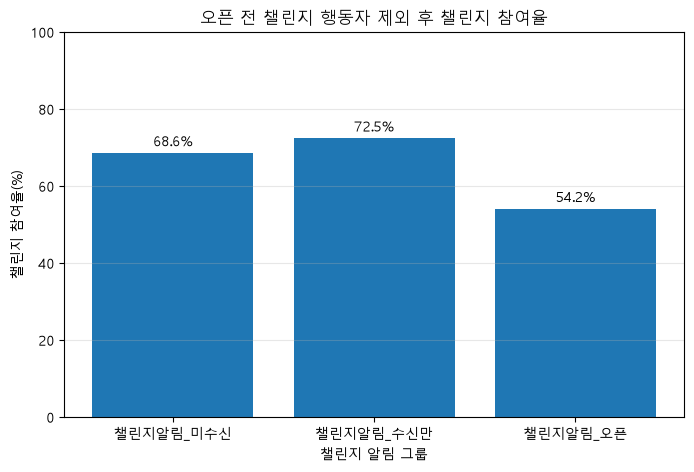

In [82]:
# ============================================================
# 오픈 전 챌린지 행동자 제외 후 참여율 시각화
# ============================================================

group_order = [
    "챌린지알림_미수신",
    "챌린지알림_수신만",
    "챌린지알림_오픈"
]

plot_df = (
    challenge_no_prior_summary
    .set_index("challenge_alarm_group")
    .reindex(group_order)
    .reset_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_df["challenge_alarm_group"],
    plot_df["participation_rate"]
)

plt.title("오픈 전 챌린지 행동자 제외 후 챌린지 참여율")
plt.xlabel("챌린지 알림 그룹")
plt.ylabel("챌린지 참여율(%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

# 막대 위에 값 표시
for bar, rate in zip(bars, plot_df["participation_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [83]:
# ============================================================
# 제외 전 vs 제외 후 참여율 비교용 데이터 생성
# ============================================================

before_df = (
    challenge_alarm_group_summary[
        ["challenge_alarm_group", "challenge_participation_rate"]
    ]
    .rename(columns={
        "challenge_participation_rate": "제외 전"
    })
)

after_df = (
    challenge_no_prior_summary[
        ["challenge_alarm_group", "participation_rate"]
    ]
    .rename(columns={
        "participation_rate": "제외 후"
    })
)

compare_participation = before_df.merge(
    after_df,
    on="challenge_alarm_group",
    how="inner"
)

compare_participation = (
    compare_participation
    .set_index("challenge_alarm_group")
    .reindex(group_order)
    .reset_index()
)

display(compare_participation)

,challenge_alarm_group,제외 전,제외 후
0,챌린지알림_미수신,68.648390,68.648390
1,챌린지알림_수신만,72.466667,72.466667
2,챌린지알림_오픈,86.515809,54.162276


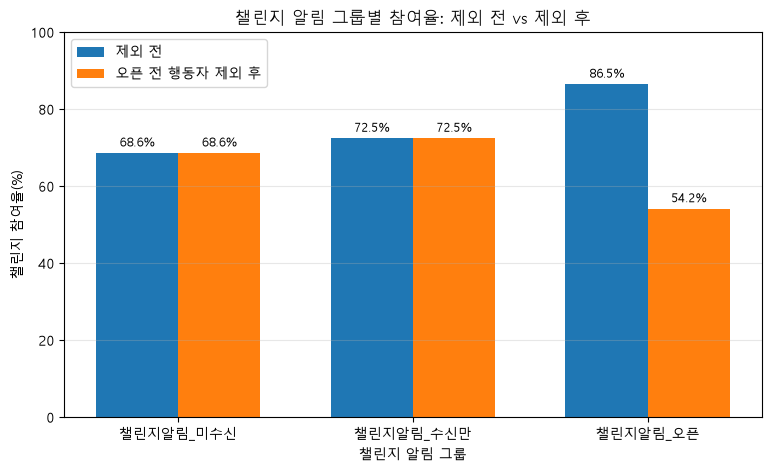

In [84]:
# ============================================================
# 제외 전 vs 제외 후 참여율 비교 시각화
# ============================================================

x = np.arange(len(compare_participation))
width = 0.35

plt.figure(figsize=(9, 5))

bars1 = plt.bar(
    x - width / 2,
    compare_participation["제외 전"],
    width,
    label="제외 전"
)

bars2 = plt.bar(
    x + width / 2,
    compare_participation["제외 후"],
    width,
    label="오픈 전 행동자 제외 후"
)

plt.title("챌린지 알림 그룹별 참여율: 제외 전 vs 제외 후")
plt.xlabel("챌린지 알림 그룹")
plt.ylabel("챌린지 참여율(%)")
plt.xticks(x, compare_participation["challenge_alarm_group"])
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.legend()

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

In [81]:
contingency_no_prior, overall_no_prior, group_summary_no_prior, pairwise_no_prior = chi_square_with_pairwise(
    df=challenge_user_base_no_prior,
    group_col="challenge_alarm_group",
    outcome_col="has_challenge_participation",
    group_order=group_order
)

,not_participated,participated
challenge_alarm_group,,
챌린지알림_미수신,1967,4307
챌린지알림_수신만,826,2174
챌린지알림_오픈,435,514


[전체 카이제곱 검정 + 효과크기]


,test,chi2,dof,p_value,n,min_expected_count,cramers_v,cramers_v_corrected
0,chi-square,112.179206,2,4.371141e-25,10223,299.654896,0.104753,0.10382


[그룹별 챌린지 참여율]


,challenge_alarm_group,not_participated,participated,users,participation_rate
0,챌린지알림_미수신,1967,4307,6274,68.648390
1,챌린지알림_수신만,826,2174,3000,72.466667
2,챌린지알림_오픈,435,514,949,54.162276


[페어와이즈 검정 + 효과크기]


,group_a,group_b,test,n,group_a_rate_pct,group_b_rate_pct,risk_diff_b_minus_a_pctp,relative_risk_b_vs_a,odds_ratio_b_vs_a,phi_abs,phi_signed,p_raw,min_expected_count,p_bh
2,챌린지알림_수신만,챌린지알림_오픈,chi-square,3949,72.466667,54.162276,-18.304391,0.747426,0.449035,0.167756,-0.167756,5.534726e-26,303.035958,1.660418e-25
1,챌린지알림_미수신,챌린지알림_오픈,chi-square,7223,68.648390,54.162276,-14.486114,0.788951,0.539618,0.103873,-0.103873,1.065896e-18,315.588814,1.598844e-18
0,챌린지알림_미수신,챌린지알림_수신만,chi-square,9274,68.648390,72.466667,3.818276,1.055557,1.201728,0.038935,0.038935,1.771633e-04,903.493638,1.771633e-04
